# ThermoWatch AI — Full Multi-File Prototype (Demo Edition)

**Smart India Hackathon — Problem Statement 26162**
*AI-Based Detection and Classification of Industrial Fires and Persistent Thermal Sources Using NASA FIRMS, OSM & Satellite Data*

This notebook is the live-demo build of ThermoWatch AI. It writes **16 real Python modules** to
disk (one `%%writefile` cell each, so they exist as actual files you can open, not just notebook
cells), imports them like a real package, and runs the full 3-layer architecture from the team's
design doc end-to-end on **real, named, famous Indian thermal sites** — not toy coordinates.

## What's REAL vs. what's a labeled PLACEHOLDER

Every module's docstring says this explicitly, but here's the one-table summary — memorize this
before a judge asks, because the honest answer is what makes this project credible:

| Piece | Status | Detail |
|---|---|---|
| Satellite image fetch | **REAL** | Live Esri World Imagery / EOX Sentinel-2 Cloudless tiles for the exact coordinate |
| Image processing (grayscale, blur, sharpen, edges, k-means segmentation) | **REAL** | Genuine pixel-level algorithms (PIL, scikit-learn KMeans) |
| "Thermal" colormap views & vegetation index | **SIMULATED** | Visible-light RGB remapped through a heat colormap — not a real thermal/NIR sensor band |
| OpenStreetMap nearest-facility lookup | **REAL** | Live Overpass API query |
| NASA POWER weather/soil context | **REAL** | Live daily temperature/humidity/rainfall/soil-moisture API |
| Reverse geocoding | **REAL** | Live OpenStreetMap Nominatim API |
| Vision branch (Branch A) | **PLACEHOLDER** | Calls Gemini as a stand-in for the trained CNN described in the architecture doc |
| Context branch (Branch B) | **REAL MODEL, SYNTHETIC DATA** | A genuine scikit-learn Random Forest — trained on a synthetic dataset because no labeled CSV exists yet |
| Temporal branch (Branch C) | **REAL MATH, SIMULATED HISTORY** | Real z-score anomaly detection, run on a simulated 30-day FRP history (no FIRMS archive pull yet) |
| Fusion engine (Layer 3) | **REAL** | Deterministic weighted-average formula, exactly as specified in the architecture doc's "Model 0" |
| Model evaluation dashboard | **REAL METRICS, SYNTHETIC DATA** | Genuine held-out confusion matrix / ROC / PR curve — describes how well the model learned its own synthetic rule |
| Stability check | **REAL** | Actual Monte Carlo re-run of the real fusion formula under input jitter |
| Multi-class breakdown | **HEURISTIC** | Explainable rule-based redistribution across 7 classes — not a trained multi-class model |

See `explain.md` in the repo root for the full write-up.

## Locations used in this demo

Five real, documented Indian sites, chosen so every SIH problem-statement class has a genuine
real-world example — see `locations.py`.

## 1. Install dependencies

In [1]:
!pip install -q -r requirements.txt
# If requirements.txt isn't present in this Colab runtime, install directly:
!pip install -q requests pillow numpy pandas scikit-learn matplotlib google-genai python-dotenv folium

## 2. Write every module to disk

Each cell below is `%%writefile <name>.py` — after running these, the files genuinely exist on disk (check the Colab file browser), and every import below is a real import of a real file, not notebook-only code.

### `utils.py`

In [2]:
%%writefile utils.py
"""
utils.py
--------
Shared helpers used across every module in this prototype: config, distance
math, and small formatting helpers. Nothing here is "fake" — this is real,
reusable plumbing.
"""
import math
from dataclasses import dataclass


@dataclass
class PipelineConfig:
    image_buffer_deg: float = 0.012      # ~1.3 km box around the point
    image_size: int = 512
    overpass_radius_m: int = 2000
    request_timeout: int = 30
    random_seed: int = 42


def haversine_m(lat1, lon1, lat2, lon2):
    """Distance in meters between two lat/lon points."""
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def coord_seed(lat: float, lon: float) -> int:
    """Turn a coordinate into a stable random seed, so 'simulated' data for the
    same location looks the same every time you run the demo (important for
    rehearsing a pitch)."""
    return abs(int((lat * 1000003 + lon * 999983))) % (2**31 - 1)


def pct(x, digits=1):
    return f"{round(x, digits)}%"


def banner(text: str):
    print("\n" + "=" * 70)
    print(text)
    print("=" * 70)


Overwriting utils.py


### `locations.py`

In [3]:
%%writefile locations.py
"""
locations.py
------------
REAL, named locations used for the live demo — not random points. Each one
is a well-documented site chosen because NASA FIRMS genuinely detects
thermal activity there, for a genuinely different underlying reason, which
is exactly the ambiguity ThermoWatch AI exists to resolve. Coordinates are
site-level approximations (a few hundred metres), which is the right
precision for a satellite-image bounding box and a live demo narration —
not for navigation.
"""

DEMO_LOCATIONS = {
    "jamnagar_refinery": {
        "label": "Reliance Jamnagar Refinery Complex, Gujarat",
        "lat": 22.3350,
        "lon": 69.8397,
        "expected_class": "persistent_industrial_source",
        "story": (
            "The single largest oil refining complex on Earth — roughly "
            "1.24 million barrels/day of capacity. Its flare stacks and "
            "process heaters run hot every single night of the year. This "
            "is the textbook 'persistent industrial source': FIRMS lights "
            "up here on repeat, and it is never a wildfire and never news."
        ),
    },
    "jharia_coalfield": {
        "label": "Jharia Coalfield, Jharkhand",
        "lat": 23.7401,
        "lon": 86.4141,
        "expected_class": "persistent_industrial_source",
        "story": (
            "Underground coal-seam fires here have burned continuously "
            "since 1916 — over a century straight. Entire towns have been "
            "relocated because the ground itself is on fire. One of the "
            "most extreme real-world 'persistent thermal source' cases "
            "on the planet, and a genuinely dramatic demo location."
        ),
    },
    "hazira_gas_complex": {
        "label": "Hazira Gas & Petrochemical Complex, Surat, Gujarat",
        "lat": 21.1167,
        "lon": 72.6500,
        "expected_class": "gas_flare",
        "story": (
            "A major onshore gas-processing and flaring hub on India's "
            "west coast (ONGC + private operators). A routine, nightly "
            "gas-flare thermal signature — different root cause from a "
            "refinery, same 'why is this hot every night' question."
        ),
    },
    "punjab_stubble_belt": {
        "label": "Punjab Stubble-Burning Belt, near Patiala",
        "lat": 30.3398,
        "lon": 76.3869,
        "expected_class": "agricultural_burn",
        "story": (
            "Every October-November this belt lights up with thousands of "
            "FIRMS detections within days, as farmers burn paddy stubble "
            "ahead of the wheat season — a massive, recurring, seasonal "
            "'agricultural burn' signature that swamps raw hotspot feeds "
            "every single year and is a real, cited air-quality crisis."
        ),
    },
    "bandipur_forest": {
        "label": "Bandipur National Park, Karnataka",
        "lat": 11.6717,
        "lon": 76.6344,
        "expected_class": "wildfire",
        "story": (
            "Dry deciduous forest that has suffered major wildfire seasons "
            "(notably February 2019). No industry, no facility, no flare "
            "stack nearby — the clean 'wildfire' control case that proves "
            "the system doesn't just call everything industrial."
        ),
    },
}


def location_summary_table() -> str:
    """Small text table for quick printing in a notebook cell."""
    lines = [f"{'Key':<22}{'Location':<45}{'Expected class':<28}Lat/Lon"]
    lines.append("-" * 110)
    for key, site in DEMO_LOCATIONS.items():
        lines.append(
            f"{key:<22}{site['label']:<45}{site['expected_class']:<28}"
            f"{site['lat']:.4f}, {site['lon']:.4f}"
        )
    return "\n".join(lines)


Overwriting locations.py


### `geo_lookup.py`

In [4]:
%%writefile geo_lookup.py
"""
geo_lookup.py
-------------
REAL module: reverse-geocodes a coordinate into a human-readable place name
using OpenStreetMap's free Nominatim API. No key needed — only a descriptive
User-Agent, which Nominatim's usage policy requires of every client.
"""
import requests

NOMINATIM_URL = "https://nominatim.openstreetmap.org/reverse"
_HEADERS = {"User-Agent": "ThermoWatchAI-SIH26162-Prototype/1.0 (student hackathon demo)"}


def reverse_geocode(lat: float, lon: float, timeout: int = 15) -> dict:
    """Returns {'display_name', 'address'}; a safe fallback dict on failure
    so a flaky network never breaks the rest of the pipeline."""
    params = {"lat": lat, "lon": lon, "format": "jsonv2", "zoom": 14}
    try:
        resp = requests.get(NOMINATIM_URL, params=params, headers=_HEADERS, timeout=timeout)
        resp.raise_for_status()
        data = resp.json()
        return {
            "display_name": data.get("display_name", "Unknown location"),
            "address": data.get("address", {}),
        }
    except Exception as e:
        print(f"[geo_lookup] Nominatim reverse geocode failed: {e}")
        return {"display_name": "Unknown location (lookup failed)", "address": {}}


Overwriting geo_lookup.py


### `image_fetcher.py`

In [5]:
%%writefile image_fetcher.py
"""
image_fetcher.py
----------------
REAL module: fetches an actual satellite/aerial image for a coordinate.
Tries Esri World Imagery first (free, no key), falls back to EOX Sentinel-2
Cloudless (free, no key) if that fails.
"""
import io
import requests
from PIL import Image
from utils import PipelineConfig


def _esri_url(lat, lon, cfg: PipelineConfig):
    d = cfg.image_buffer_deg
    return (
        "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/export"
        f"?bbox={lon-d},{lat-d},{lon+d},{lat+d}&bboxSR=4326&imageSR=4326"
        f"&size={cfg.image_size},{cfg.image_size}&format=png32&f=image"
    )


def _eox_url(lat, lon, cfg: PipelineConfig):
    d = cfg.image_buffer_deg
    return (
        "https://tiles.maps.eox.at/wms?service=WMS&request=GetMap&version=1.1.1"
        "&layers=s2cloudless-2023&styles=&format=image/png"
        f"&bbox={lon-d},{lat-d},{lon+d},{lat+d}&srs=EPSG:4326"
        f"&width={cfg.image_size}&height={cfg.image_size}"
    )


def fetch_satellite_image(lat: float, lon: float, cfg: PipelineConfig = None) -> Image.Image:
    """Returns a PIL Image. Raises RuntimeError only if every source fails."""
    cfg = cfg or PipelineConfig()
    errors = []
    for name, url_fn in [("Esri World Imagery", _esri_url), ("EOX Sentinel-2 Cloudless", _eox_url)]:
        try:
            url = url_fn(lat, lon, cfg)
            resp = requests.get(url, timeout=cfg.request_timeout)
            resp.raise_for_status()
            img = Image.open(io.BytesIO(resp.content)).convert("RGB")
            print(f"[image_fetcher] got image from {name}")
            return img
        except Exception as e:
            errors.append(f"{name}: {e}")

    raise RuntimeError("All imagery sources failed:\n" + "\n".join(errors))


Overwriting image_fetcher.py


### `image_processing.py`

In [6]:
%%writefile image_processing.py
"""
image_processing.py
--------------------
REAL module: every transformation here actually runs on the real pixels of
the fetched image using standard, well-known algorithms (grayscale, Sobel
edge detection, Gaussian blur, k-means segmentation, colormap remapping).

One honest labeling note: the "thermal" and "vegetation index" views below
are VISUAL SIMULATIONS built by remapping ordinary RGB pixels through a
colormap or a formula — they are NOT real thermal-band or NIR-band data
(that would require a real thermal sensor / Sentinel-2 NIR band, which the
production system uses; see the architecture PDF). They exist here purely
to make the demo gallery look like a real remote-sensing pipeline. Say this
plainly if a judge asks.
"""
from collections import OrderedDict

import numpy as np
from PIL import Image, ImageFilter, ImageEnhance, ImageOps
import matplotlib
from sklearn.cluster import KMeans


def to_grayscale(img: Image.Image) -> Image.Image:
    return ImageOps.grayscale(img)


def apply_blur(img: Image.Image, radius: int = 4) -> Image.Image:
    return img.filter(ImageFilter.GaussianBlur(radius=radius))


def apply_sharpen(img: Image.Image) -> Image.Image:
    return img.filter(ImageFilter.SHARPEN)


def apply_contrast(img: Image.Image, factor: float = 1.6) -> Image.Image:
    return ImageEnhance.Contrast(img).enhance(factor)


def edge_detection(img: Image.Image) -> Image.Image:
    """Real Sobel-style edge detection via PIL's built-in edge filter."""
    gray = ImageOps.grayscale(img)
    return gray.filter(ImageFilter.FIND_EDGES)


def _colormap_image(gray_img: Image.Image, cmap_name: str) -> Image.Image:
    arr = np.asarray(gray_img).astype(np.float32) / 255.0
    colored = matplotlib.colormaps[cmap_name](arr)  # RGBA in [0,1]; matplotlib.cm.get_cmap was removed in mpl 3.9+
    colored_rgb = (colored[:, :, :3] * 255).astype(np.uint8)
    return Image.fromarray(colored_rgb)


def simulated_thermal_view(img: Image.Image, cmap_name: str = "inferno") -> Image.Image:
    """NOTE: simulated — remaps visible brightness through a heat-style
    colormap. Looks like a thermal camera; is not one."""
    gray = ImageOps.grayscale(img)
    return _colormap_image(gray, cmap_name)


def binary_hotspot_mask(img: Image.Image, percentile: float = 92.0) -> Image.Image:
    """Flags the brightest N% of pixels as a stand-in 'hotspot' mask.
    NOTE: simulated — a real system thresholds actual FRP/brightness-
    temperature values from the sensor, not visible-light brightness."""
    gray = np.asarray(ImageOps.grayscale(img)).astype(np.float32)
    thresh = np.percentile(gray, percentile)
    mask = (gray >= thresh).astype(np.uint8) * 255
    return Image.fromarray(mask)


def kmeans_segmentation(img: Image.Image, k: int = 4) -> Image.Image:
    """REAL unsupervised segmentation — actually clusters the image's pixel
    colors with k-means. This is a legitimate, if simple, computer-vision
    technique (not a trained classifier)."""
    small = img.resize((128, 128))
    arr = np.asarray(small).reshape(-1, 3).astype(np.float32)
    km = KMeans(n_clusters=k, n_init=4, random_state=42).fit(arr)
    labels = km.labels_.reshape(128, 128)
    palette = (matplotlib.colormaps["tab10"](np.linspace(0, 1, k))[:, :3] * 255).astype(np.uint8)
    seg = palette[labels]
    return Image.fromarray(seg).resize(img.size, Image.NEAREST)


def simulated_vegetation_index(img: Image.Image) -> Image.Image:
    """NOTE: simulated — approximates a vegetation-index-style view using only
    RGB (green vs red channel difference) as a stand-in. The production
    system uses real Sentinel-2 NIR+Red bands (true NDVI)."""
    arr = np.asarray(img).astype(np.float32)
    r, g = arr[:, :, 0], arr[:, :, 1]
    pseudo_ndvi = (g - r) / (g + r + 1e-6)
    normed = (pseudo_ndvi - pseudo_ndvi.min()) / (pseudo_ndvi.max() - pseudo_ndvi.min() + 1e-6)
    return _colormap_image(Image.fromarray((normed * 255).astype(np.uint8)), "RdYlGn")


def quadrant_split(img: Image.Image):
    """Splits the image into 4 quadrants — the 'zoom-in' dashboard feature
    discussed in the architecture doc (demo-only visual, not the core
    classification mechanism)."""
    w, h = img.size
    boxes = [(0, 0, w // 2, h // 2), (w // 2, 0, w, h // 2),
             (0, h // 2, w // 2, h), (w // 2, h // 2, w, h)]
    return [img.crop(b) for b in boxes]


def build_processing_gallery(img: Image.Image) -> "OrderedDict[str, Image.Image]":
    """Runs every transform above and returns a labeled, ordered gallery
    ready to be plotted in a grid. This alone gives 12+ distinct panels."""
    gallery = OrderedDict()
    gallery["1. Original satellite image"] = img
    gallery["2. Grayscale"] = to_grayscale(img)
    gallery["3. Gaussian blur"] = apply_blur(img)
    gallery["4. Sharpened"] = apply_sharpen(img)
    gallery["5. Contrast enhanced"] = apply_contrast(img)
    gallery["6. Edge detection (Sobel-style)"] = edge_detection(img)
    gallery["7. Simulated thermal (inferno)"] = simulated_thermal_view(img, "inferno")
    gallery["8. Simulated thermal (jet)"] = simulated_thermal_view(img, "jet")
    gallery["9. Simulated thermal (hot)"] = simulated_thermal_view(img, "hot")
    gallery["10. Simulated hotspot mask (B/W)"] = binary_hotspot_mask(img)
    gallery["11. K-means segmentation (k=4)"] = kmeans_segmentation(img, k=4)
    gallery["12. Simulated vegetation index"] = simulated_vegetation_index(img)
    quads = quadrant_split(img)
    for i, q in enumerate(quads, start=1):
        gallery[f"{12+i}. Zoom quadrant {i}/4"] = q
    return gallery


Overwriting image_processing.py


### `context_fetcher.py`

In [7]:
%%writefile context_fetcher.py
"""
context_fetcher.py
-------------------
REAL module: pulls actual context data from free public APIs —
OpenStreetMap (nearest industrial facility) and NASA POWER (weather/soil).
Nothing simulated in this file.
"""
import datetime
import requests
from utils import PipelineConfig, haversine_m

# Public Overpass mirrors, tried in order. overpass-api.de rejects requests
# with no Accept header (406) and is sometimes slow, so we send a proper
# header set, use a generous timeout, and fail over to a second mirror.
_OVERPASS_URLS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
]
_OVERPASS_HEADERS = {
    "User-Agent": "ThermoWatchAI-SIH26162-Prototype/1.0 (student hackathon demo)",
    "Accept": "*/*",
}


def get_nearest_industrial_facility(lat, lon, cfg: PipelineConfig = None):
    cfg = cfg or PipelineConfig()
    r = cfg.overpass_radius_m
    query = f"""
    [out:json][timeout:25];
    (
      node["landuse"="industrial"](around:{r},{lat},{lon});
      way["landuse"="industrial"](around:{r},{lat},{lon});
      node["man_made"~"works|petroleum_well|chimney"](around:{r},{lat},{lon});
      way["man_made"~"works|petroleum_well|chimney"](around:{r},{lat},{lon});
      node["power"="plant"](around:{r},{lat},{lon});
      way["power"="plant"](around:{r},{lat},{lon});
    );
    out center;
    """
    result = {"nearest_industrial_facility": None, "facility_distance_m": None}
    overpass_timeout = max(cfg.request_timeout, 40)
    elements = None
    for url in _OVERPASS_URLS:
        try:
            resp = requests.post(url, data={"data": query}, headers=_OVERPASS_HEADERS, timeout=overpass_timeout)
            resp.raise_for_status()
            elements = resp.json().get("elements", [])
            break
        except Exception as e:
            print(f"[context_fetcher] OSM lookup via {url} failed: {e}")

    if elements is None:
        return result

    best_name, best_dist = None, None
    for el in elements:
        tags = el.get("tags", {})
        elat = el.get("lat") or (el.get("center", {}) or {}).get("lat")
        elon = el.get("lon") or (el.get("center", {}) or {}).get("lon")
        if elat is None or elon is None:
            continue
        dist = haversine_m(lat, lon, elat, elon)
        if best_dist is None or dist < best_dist:
            best_dist = dist
            best_name = tags.get("name") or tags.get("man_made") or tags.get("power") or "unnamed industrial site"
    result["nearest_industrial_facility"] = best_name
    result["facility_distance_m"] = round(best_dist, 1) if best_dist is not None else None
    return result


def get_weather_soil_context(lat, lon, cfg: PipelineConfig = None, days_back: int = 7):
    cfg = cfg or PipelineConfig()
    end_date = datetime.date.today() - datetime.timedelta(days=2)
    start_date = end_date - datetime.timedelta(days=days_back)
    params = {
        "parameters": "T2M,RH2M,PRECTOTCORR,GWETROOT",
        "community": "AG",
        "longitude": lon, "latitude": lat,
        "start": start_date.strftime("%Y%m%d"), "end": end_date.strftime("%Y%m%d"),
        "format": "JSON",
    }
    out = {"avg_temp_c": None, "avg_humidity_pct": None, "avg_rainfall_mm": None, "avg_root_zone_soil_moisture": None}
    try:
        resp = requests.get("https://power.larc.nasa.gov/api/temporal/daily/point", params=params, timeout=cfg.request_timeout)
        resp.raise_for_status()
        data = resp.json()["properties"]["parameter"]

        def avg(series):
            vals = [v for v in series.values() if v not in (-999, None)]
            return round(sum(vals) / len(vals), 2) if vals else None

        out["avg_temp_c"] = avg(data.get("T2M", {}))
        out["avg_humidity_pct"] = avg(data.get("RH2M", {}))
        out["avg_rainfall_mm"] = avg(data.get("PRECTOTCORR", {}))
        out["avg_root_zone_soil_moisture"] = avg(data.get("GWETROOT", {}))
    except Exception as e:
        print(f"[context_fetcher] NASA POWER lookup failed: {e}")
    return out


def get_full_context(lat, lon, cfg: PipelineConfig = None):
    ctx = get_nearest_industrial_facility(lat, lon, cfg)
    ctx.update(get_weather_soil_context(lat, lon, cfg))
    return ctx


Overwriting context_fetcher.py


### `gemini_setup.py`

In [8]:
%%writefile gemini_setup.py
"""
gemini_setup.py
----------------
Loads a Gemini API key from the environment (a local .env file, a Colab
secret, or manual getpass input) and returns a configured GenerativeModel.
This IS the placeholder standing in for the trained CNN in vision_model.py
(see that file's docstring) — swapping it for a real fine-tuned model later
only touches vision_model.py, not this file or the pipeline.

SECURITY NOTE: never hardcode your real API key into a tracked .py or
.ipynb file. Put it in a local .env file (already gitignored in this repo,
see .env.example) or Colab's "Secrets" panel, and load it from there. If a
key was ever pasted into a chat, a doc, or a commit, treat it as burned and
regenerate it in Google AI Studio (https://aistudio.google.com/apikey).
"""
import os

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

try:
    from google import genai  # the current, supported SDK (pip install google-genai)
    _GEMINI_AVAILABLE = True
except ImportError:
    _GEMINI_AVAILABLE = False

DEFAULT_MODEL_NAME = os.getenv("GEMINI_MODEL", "gemini-2.5-flash")


class GeminiModel:
    """Thin wrapper around google-genai's Client so vision_model.py can call
    `.generate_content([...])` the same way regardless of SDK generation —
    the new SDK calls generate_content on the client, not on a per-model
    object, so this just remembers which model name to pass each time."""

    def __init__(self, client, model_name: str):
        self.client = client
        self.model_name = model_name

    def generate_content(self, parts):
        return self.client.models.generate_content(model=self.model_name, contents=parts)


def configure_gemini(api_key: str = None, model_name: str = None):
    """Returns a ready-to-use GeminiModel, or None if unavailable/no key is
    found — the pipeline still runs end-to-end either way, because
    vision_model.run_vision_branch() falls back to a deterministic
    simulated response when no model is passed in.

    Note: even with a valid key, Google's free tier restricts which models
    are usable per-project. If every call fails with 403/404/429, check
    https://aistudio.google.com/apikey for your project's billing/model
    access — the vision branch will keep working via its simulated
    fallback in the meantime, clearly labeled as such in its output."""
    if not _GEMINI_AVAILABLE:
        print("[gemini_setup] google-genai not installed — vision branch will use the simulated fallback.")
        return None

    key = api_key or os.getenv("GEMINI_API_KEY")
    if not key:
        print("[gemini_setup] No GEMINI_API_KEY found (checked argument + .env) — "
              "vision branch will use the simulated fallback.")
        return None

    resolved_model_name = model_name or DEFAULT_MODEL_NAME
    client = genai.Client(api_key=key)
    print(f"[gemini_setup] Gemini configured — model '{resolved_model_name}' ready "
          f"(falls back to simulated response per-call if the API rejects the request).")
    return GeminiModel(client, resolved_model_name)


Overwriting gemini_setup.py


### `vision_model.py`

In [9]:
%%writefile vision_model.py
"""
vision_model.py  (Branch A — "Vision CNN")
-------------------------------------------
DEMO-ONLY MODULE, clearly labeled.

In the real architecture, this file is a Convolutional Neural Network
(ResNet/EfficientNet) trained on our own labeled satellite-image dataset
(see the FlareSat / Kaggle datasets in the architecture PDF).

For today's PROTOTYPE, this file calls Google's Gemini vision model instead,
so the pipeline runs end-to-end right now while the real CNN is being
trained. The function names below intentionally mirror what the real CNN
module's interface will look like, so swapping it in later is a one-file
change, not a rewrite of the whole pipeline.

Say this plainly in your pitch: "this block is a placeholder standing in for
our CNN while it trains."
"""
import io
import json
import random

import numpy as np
from PIL import Image

try:
    from google.genai import types as genai_types
    _GEMINI_AVAILABLE = True
except ImportError:
    _GEMINI_AVAILABLE = False

from utils import coord_seed

VISION_PROMPT = """You are simulating one branch of a fire-classification system:
a computer-vision model looking ONLY at a satellite image (no other context).

Look at this satellite image and judge whether the surroundings look more
INDUSTRIAL (buildings, tanks, roads, bare/paved ground, factories) or more
NATURAL (forest, farmland, grass, undeveloped land).

Respond with ONLY valid JSON, no other text:
{
  "industrial_probability_percent": <integer 0-100>,
  "natural_probability_percent": <integer 0-100 -- should sum to ~100 with the above>,
  "visual_notes": ["<short observation 1>", "<short observation 2>"]
}
"""


def _parse_json(raw_text: str) -> dict:
    cleaned = raw_text.strip().strip("`")
    if cleaned.lower().startswith("json"):
        cleaned = cleaned[4:]
    return json.loads(cleaned.strip())


def run_vision_branch(image: Image.Image, lat: float, lon: float, gemini_model=None) -> dict:
    """Returns the vision branch's opinion. Uses Gemini if a model object is
    passed in; otherwise falls back to a deterministic simulated response
    (so the notebook still runs end-to-end even with no API key / no quota,
    e.g. for a quick offline rehearsal)."""
    if gemini_model is not None and _GEMINI_AVAILABLE:
        try:
            buf = io.BytesIO()
            image.save(buf, format="PNG")
            image_part = genai_types.Part.from_bytes(data=buf.getvalue(), mime_type="image/png")
            response = gemini_model.generate_content([VISION_PROMPT, image_part])
            result = _parse_json(response.text)
            result["source"] = f"gemini_vision:{getattr(gemini_model, 'model_name', 'unknown')} (placeholder for trained CNN)"
            return result
        except Exception as e:
            print(f"[vision_model] Gemini call failed, falling back to simulated response: {e}")

    # --- Deterministic simulated fallback (no API key / offline rehearsal) ---
    rng = random.Random(coord_seed(lat, lon))
    industrial_p = rng.randint(20, 95)
    return {
        "industrial_probability_percent": industrial_p,
        "natural_probability_percent": 100 - industrial_p,
        "visual_notes": ["[simulated — no Gemini call made]"],
        "source": "simulated_fallback",
    }


def fake_activation_chart_values(lat: float, lon: float, n_filters: int = 16):
    """PURELY DECORATIVE — generates plausible-looking 'CNN filter activation'
    bar values for the dashboard visual. These are NOT real network
    activations (there is no trained network in this prototype). Label any
    chart built from this clearly as illustrative."""
    rng = np.random.RandomState(coord_seed(lat, lon) % (2**31 - 1))
    return rng.beta(2, 2, size=n_filters)


Overwriting vision_model.py


### `tabular_model.py`

In [10]:
%%writefile tabular_model.py
"""
tabular_model.py  (Branch B — "Context / Tabular Model")
----------------------------------------------------------
HONEST HYBRID MODULE: the MODEL ITSELF is real — an actual scikit-learn
Random Forest that really fits and really predicts. What's fake is the
TRAINING DATA: since the team doesn't have a real labeled dataset yet, this
file generates a synthetic training set with rules loosely inspired by the
research roadmap (closer to industry + drier soil -> more "industrial"-like
patterns) purely so the model has something to learn from for the demo.

Swap `_generate_synthetic_training_data()` for a real labeled CSV
(thermal_event_dataset.csv from the other notebooks) and everything else in
this file works unchanged. That's the point of building it this way.
"""
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

FEATURE_NAMES = [
    "facility_distance_m", "avg_temp_c", "avg_humidity_pct",
    "avg_rainfall_mm", "avg_root_zone_soil_moisture",
]


def _generate_synthetic_training_data(n=800, seed=42):
    """SIMULATED training set — for demo purposes only. Replace with real
    labeled data before this leaves prototype stage."""
    rng = np.random.RandomState(seed)
    facility_distance_m = rng.exponential(scale=1500, size=n)
    avg_temp_c = rng.normal(30, 5, size=n)
    avg_humidity_pct = rng.uniform(20, 90, size=n)
    avg_rainfall_mm = rng.exponential(scale=2, size=n)
    avg_root_zone_soil_moisture = rng.uniform(0.05, 0.6, size=n)

    # Rough synthetic rule: close to industry + low rainfall -> "industrial"
    industrial_score = (
        (1 / (1 + facility_distance_m / 500))
        + (1 - avg_root_zone_soil_moisture)
        - (avg_rainfall_mm / 10)
    )
    label = (industrial_score > np.median(industrial_score)).astype(int)  # 1 = industrial-like

    df = pd.DataFrame({
        "facility_distance_m": facility_distance_m,
        "avg_temp_c": avg_temp_c,
        "avg_humidity_pct": avg_humidity_pct,
        "avg_rainfall_mm": avg_rainfall_mm,
        "avg_root_zone_soil_moisture": avg_root_zone_soil_moisture,
        "label": label,
    })
    return df


def train_prototype_model(seed=42) -> RandomForestClassifier:
    df = _generate_synthetic_training_data(seed=seed)
    X = df[FEATURE_NAMES]
    y = df["label"]
    clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=seed)
    clf.fit(X, y)
    return clf


def run_context_branch(context: dict, clf: RandomForestClassifier = None) -> dict:
    """Predicts on REAL fetched context data (facility distance, weather,
    soil moisture) using the model above. The prediction call itself is a
    genuine model.predict_proba — only the training data behind it is
    synthetic."""
    clf = clf or train_prototype_model()

    row = {
        "facility_distance_m": context.get("facility_distance_m") if context.get("facility_distance_m") is not None else 5000,
        "avg_temp_c": context.get("avg_temp_c") if context.get("avg_temp_c") is not None else 28.0,
        "avg_humidity_pct": context.get("avg_humidity_pct") if context.get("avg_humidity_pct") is not None else 50.0,
        "avg_rainfall_mm": context.get("avg_rainfall_mm") if context.get("avg_rainfall_mm") is not None else 1.0,
        "avg_root_zone_soil_moisture": context.get("avg_root_zone_soil_moisture") if context.get("avg_root_zone_soil_moisture") is not None else 0.3,
    }
    X = pd.DataFrame([row])[FEATURE_NAMES]
    proba = clf.predict_proba(X)[0]  # [P(natural), P(industrial)]
    importances = dict(zip(FEATURE_NAMES, clf.feature_importances_))

    return {
        "industrial_probability_percent": round(float(proba[1]) * 100, 1),
        "natural_probability_percent": round(float(proba[0]) * 100, 1),
        "feature_importances": importances,
        "source": "random_forest (trained on SYNTHETIC placeholder data)",
    }


Overwriting tabular_model.py


### `temporal_model.py`

In [11]:
%%writefile temporal_model.py
"""
temporal_model.py  (Branch C — "Temporal / Persistence Model")
------------------------------------------------------------------
HONEST HYBRID MODULE: the underlying 30-day detection history plotted here
is SIMULATED (deterministically, from the coordinate, so it's stable across
demo runs) because a real facility-level FIRMS history requires the archive
pull described in the architecture PDF. The anomaly-score MATH (rolling
mean, standard deviation, z-score) is real and would work unchanged on a
real history once you plug one in.
"""
import numpy as np
from utils import coord_seed


def simulate_thermal_history(lat: float, lon: float, days: int = 30):
    """SIMULATED — deterministic per-coordinate synthetic FRP history.
    Replace with a real FIRMS archive query (see architecture PDF, Layer 1)
    for production."""
    rng = np.random.RandomState(coord_seed(lat, lon))
    baseline = rng.uniform(20, 60)          # normal background FRP for this "site"
    noise = rng.normal(0, 5, size=days)
    history = np.clip(baseline + noise, 1, None)

    # Inject a plausible "event" on the final day so the demo has something
    # to react to — a spike a few standard deviations above baseline.
    spike_multiplier = rng.uniform(2.5, 5.0)
    history[-1] = baseline * spike_multiplier

    return history, baseline


def compute_anomaly_score(history: np.ndarray) -> dict:
    """REAL math: z-score of the latest reading against the trailing
    baseline (all but the last point)."""
    baseline_window = history[:-1]
    latest = history[-1]
    mean = float(np.mean(baseline_window))
    std = float(np.std(baseline_window)) or 1e-6
    z_score = (latest - mean) / std

    anomaly_percent = float(np.clip((z_score / 6.0) * 100, 0, 100))  # squash to 0-100
    return {
        "latest_frp": round(float(latest), 1),
        "baseline_mean_frp": round(mean, 1),
        "baseline_std_frp": round(std, 1),
        "z_score": round(z_score, 2),
        "anomaly_score_percent": round(anomaly_percent, 1),
        "is_abnormal": bool(z_score > 2.0),
    }


def run_temporal_branch(lat: float, lon: float, days: int = 30) -> dict:
    history, baseline = simulate_thermal_history(lat, lon, days=days)
    anomaly = compute_anomaly_score(history)
    anomaly["history"] = history.tolist()
    anomaly["source"] = "z-score anomaly detection (on SIMULATED history — see architecture PDF for the real FIRMS-archive version)"
    return anomaly


Overwriting temporal_model.py


### `evaluation.py`

In [12]:
%%writefile evaluation.py
"""
evaluation.py  (feeds Dashboard 4 — Model Evaluation)
-------------------------------------------------------
REAL module: every number in this file is a genuinely computed evaluation —
a real train/test split, a real confusion matrix, a real ROC curve, a real
precision-recall curve, and a real 2D decision-boundary contour, all from
scikit-learn running on a held-out split that the model never saw during
training.

The one honest caveat, inherited from tabular_model.py: the DATA underneath
is still the synthetic placeholder dataset (see that file's docstring), so
these metrics describe how well the model learned its own synthetic rule,
not real-world accuracy on real labeled events. Swap in a real labeled CSV
and every function below keeps working unchanged — that is the entire point
of separating "the model" from "the data" this way.
"""
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
)

from tabular_model import _generate_synthetic_training_data, FEATURE_NAMES


def run_holdout_evaluation(seed: int = 42, n: int = 1600, test_size: float = 0.25) -> dict:
    """Trains on 75% of the synthetic dataset, evaluates on the untouched
    25% — a genuine held-out evaluation, not a self-report on training data."""
    df = _generate_synthetic_training_data(n=n, seed=seed)
    X = df[FEATURE_NAMES]
    y = df["label"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )

    clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=seed)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_value = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    metrics = {
        "accuracy": round(float(accuracy_score(y_test, y_pred)), 3),
        "precision": round(float(precision_score(y_test, y_pred)), 3),
        "recall": round(float(recall_score(y_test, y_pred)), 3),
        "f1": round(float(f1_score(y_test, y_pred)), 3),
        "roc_auc": round(float(roc_auc_score(y_test, y_proba)), 3),
    }

    return {
        "confusion_matrix": cm,
        "fpr": fpr, "tpr": tpr, "roc_auc": roc_auc_value,
        "pr_precision": precision, "pr_recall": recall,
        "metrics": metrics,
        "clf": clf,
        "y_test": y_test.to_numpy(),
        "y_proba": y_proba,
    }


def run_2d_decision_boundary(seed: int = 42, n: int = 1600,
                              feat_x: str = "facility_distance_m",
                              feat_y: str = "avg_root_zone_soil_moisture") -> dict:
    """A second, genuinely-fit 2-feature Random Forest purely so its decision
    surface can be drawn as a 2D contour — a real model, deliberately
    restricted to 2 inputs so it can be visualized at all."""
    df = _generate_synthetic_training_data(n=n, seed=seed)
    X = df[[feat_x, feat_y]].values
    y = df["label"].values

    clf2 = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=seed)
    clf2.fit(X, y)

    x_min, x_max = X[:, 0].min() - 200, X[:, 0].max() + 200
    y_min, y_max = X[:, 1].min() - 0.02, X[:, 1].max() + 0.02
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    zz = clf2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

    return {"xx": xx, "yy": yy, "zz": zz, "X": X, "y": y, "feat_x": feat_x, "feat_y": feat_y}


Overwriting evaluation.py


### `fusion_engine.py`

In [13]:
%%writefile fusion_engine.py
"""
fusion_engine.py  (Layer 3 — AI Fusion Engine)
-------------------------------------------------
REAL module: combines the three branch outputs with a simple, transparent
weighted average — exactly the "Model 0 fusion" recommended as step one in
the architecture PDF before upgrading to a learned meta-classifier.
"""
import numpy as np

CLASS_LABELS = [
    "industrial_fire", "persistent_industrial_source", "wildfire",
    "agricultural_burn", "gas_flare", "mining_activity", "unknown",
]

DEFAULT_WEIGHTS = {"vision": 0.4, "context": 0.4, "temporal": 0.2}


def fuse_branches(vision: dict, context: dict, temporal: dict, weights: dict = None) -> dict:
    weights = weights or DEFAULT_WEIGHTS

    vision_ind = vision.get("industrial_probability_percent", 50)
    context_ind = context.get("industrial_probability_percent", 50)
    # temporal branch doesn't vote industrial-vs-natural directly, but its
    # anomaly score nudges confidence and risk
    anomaly = temporal.get("anomaly_score_percent", 0)

    fused_industrial = (
        weights["vision"] * vision_ind
        + weights["context"] * context_ind
        + weights["temporal"] * anomaly
    ) / sum(weights.values())

    fused_industrial = round(fused_industrial, 1)
    fused_natural = round(100 - fused_industrial, 1)

    if fused_industrial >= 65:
        classification = "industrial_fire" if temporal.get("is_abnormal") else "persistent_industrial_source"
    elif fused_industrial <= 35:
        classification = "wildfire"
    else:
        classification = "unknown"

    confidence = round(abs(fused_industrial - 50) * 2, 1)  # distance from "coin flip", scaled to 0-100

    risk_score = round(0.6 * confidence + 0.4 * anomaly, 1)
    risk_score = max(0, min(100, risk_score))

    return {
        "classification": classification,
        "fused_industrial_probability_percent": fused_industrial,
        "fused_natural_probability_percent": fused_natural,
        "confidence_percent": confidence,
        "risk_score": risk_score,
        "branch_votes": {
            "vision_industrial_pct": vision_ind,
            "context_industrial_pct": context_ind,
            "temporal_anomaly_pct": anomaly,
        },
        "weights_used": weights,
    }


def derive_multiclass_distribution(fusion_result: dict, temporal_result: dict, context: dict) -> dict:
    """NOTE: HEURISTIC, DEMO-ONLY — this is NOT a trained multi-class model.
    It redistributes the binary industrial/natural fusion score across the
    7 SIH problem-statement classes using simple, explainable rules, purely
    so the dashboard can show a full multi-class bar chart. A real system
    would train one multi-class model (or a proper one-vs-rest ensemble) on
    labeled examples of every class."""
    industrial = fusion_result["fused_industrial_probability_percent"]
    natural = fusion_result["fused_natural_probability_percent"]
    anomaly = temporal_result.get("anomaly_score_percent", 0)
    dist_m = context.get("facility_distance_m")
    close_to_facility = dist_m is not None and dist_m < 800

    raw = {
        "industrial_fire": industrial * (anomaly / 100) * (1.3 if close_to_facility else 0.8),
        "persistent_industrial_source": industrial * (1 - anomaly / 100) * (1.2 if close_to_facility else 0.7),
        "gas_flare": industrial * 0.35 * (1.1 if close_to_facility else 0.5),
        "mining_activity": industrial * 0.2,
        "wildfire": natural * (anomaly / 100 + 0.3),
        "agricultural_burn": natural * 0.5,
        "unknown": 5.0,
    }
    total = sum(raw.values()) or 1.0
    normalized = {k: round(100 * v / total, 1) for k, v in raw.items()}
    return normalized


def run_stability_check(vision: dict, context: dict, temporal: dict, weights: dict = None,
                         n_runs: int = 200, noise_pct: float = 0.05, seed: int = 42) -> dict:
    """REAL Monte Carlo robustness check: perturbs each branch's input signal
    by +/- noise_pct and re-runs the real fuse_branches() formula n_runs
    times. This genuinely measures how sensitive the final confidence/risk
    are to small input jitter — a real stability test, not a decorative one,
    it just happens to run on the fused numbers rather than on raw sensors."""
    rng = np.random.RandomState(seed)
    base_vision = vision.get("industrial_probability_percent", 50)
    base_context = context.get("industrial_probability_percent", 50)
    base_anomaly = temporal.get("anomaly_score_percent", 0)
    is_abnormal = temporal.get("is_abnormal", False)

    confidences, risks = [], []
    for _ in range(n_runs):
        v = float(np.clip(base_vision * (1 + rng.uniform(-noise_pct, noise_pct)), 0, 100))
        c = float(np.clip(base_context * (1 + rng.uniform(-noise_pct, noise_pct)), 0, 100))
        a = float(np.clip(base_anomaly * (1 + rng.uniform(-noise_pct, noise_pct)), 0, 100))
        result = fuse_branches(
            {"industrial_probability_percent": v},
            {"industrial_probability_percent": c},
            {"anomaly_score_percent": a, "is_abnormal": is_abnormal},
            weights=weights,
        )
        confidences.append(result["confidence_percent"])
        risks.append(result["risk_score"])

    return {
        "confidence_samples": confidences,
        "risk_samples": risks,
        "n_runs": n_runs,
        "noise_pct": noise_pct,
        "source": "Monte Carlo re-run of the real fusion formula (real math on real perturbations)",
    }


Overwriting fusion_engine.py


### `map_view.py`

In [14]:
%%writefile map_view.py
"""
map_view.py
-----------
REAL module: builds an actual interactive Leaflet map (via folium) showing
the event location and analysis-radius rings — a lightweight stand-in for
the full PostGIS + MapLibre GIS dashboard described in Layer 3 of the
architecture PDF, but a genuine, clickable, zoomable map, not a screenshot.
"""
import folium


def build_event_map(lat: float, lon: float, context: dict, label: str = "") -> folium.Map:
    m = folium.Map(location=[lat, lon], zoom_start=14, tiles="OpenStreetMap")

    dist = context.get("facility_distance_m")
    facility = context.get("nearest_industrial_facility")
    popup_lines = [f"<b>{label or 'Thermal event'}</b>", f"Lat/Lon: {lat:.4f}, {lon:.4f}"]
    if facility:
        popup_lines.append(f"Nearest OSM industrial facility: {facility} ({dist} m)")

    folium.Marker(
        [lat, lon],
        tooltip=label or "Thermal event",
        popup="<br>".join(popup_lines),
        icon=folium.Icon(color="red", icon="fire", prefix="fa"),
    ).add_to(m)

    for radius_m, color, name in [(500, "#c62828", "close zone"),
                                   (1500, "#f9a825", "medium zone"),
                                   (3000, "#2e7d32", "far zone")]:
        folium.Circle(
            [lat, lon], radius=radius_m, color=color, fill=False, weight=2,
            tooltip=f"{name}: {radius_m} m radius",
        ).add_to(m)

    return m


def build_multi_site_map(locations: dict) -> folium.Map:
    """One India-wide map with every demo location plotted and color-coded
    by its expected class — the closest thing to the full GIS dashboard's
    "map + filters" view that this notebook prototype can offer."""
    m = folium.Map(location=[22.5, 78.9], zoom_start=5, tiles="OpenStreetMap")
    color_by_class = {
        "persistent_industrial_source": "blue",
        "gas_flare": "purple",
        "agricultural_burn": "orange",
        "wildfire": "red",
        "industrial_fire": "darkred",
        "mining_activity": "cadetblue",
        "unknown": "gray",
    }
    for site in locations.values():
        folium.Marker(
            [site["lat"], site["lon"]],
            tooltip=site["label"],
            popup=f"<b>{site['label']}</b><br>{site['story']}",
            icon=folium.Icon(
                color=color_by_class.get(site["expected_class"], "gray"),
                icon="info-sign",
            ),
        ).add_to(m)
    return m


Overwriting map_view.py


### `dashboard_visuals.py`

In [15]:
%%writefile dashboard_visuals.py
"""
dashboard_visuals.py
---------------------
REAL module: every chart here is drawn from real numbers produced upstream
(fetched context, computed anomaly score, fusion output) or from clearly
labeled illustrative/decorative values (CNN activation bars). This is the
"lots of charts" file — each function below is one chart.
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from fusion_engine import CLASS_LABELS


def plot_image_gallery(gallery: dict, cols: int = 5, figsize_scale: float = 2.6):
    n = len(gallery)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_scale, rows * figsize_scale))
    axes = np.atleast_2d(axes)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (title, img) in zip(axes.flat, gallery.items()):
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        ax.set_title(title, fontsize=8.5)
        ax.axis("off")
    plt.suptitle("Image Processing Pipeline — Full Gallery", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()


def plot_branch_confidence_bars(vision, context, temporal):
    labels = ["Vision Branch\n(industrial %)", "Context Branch\n(industrial %)", "Temporal Branch\n(anomaly %)"]
    values = [
        vision.get("industrial_probability_percent", 0),
        context.get("industrial_probability_percent", 0),
        temporal.get("anomaly_score_percent", 0),
    ]
    colors = ["#1f4c8a", "#1f7a3d", "#8a1f6a"]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(labels, values, color=colors)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v}%", ha="center", fontsize=10, weight="bold")
    ax.set_ylim(0, 110)
    ax.set_ylabel("Percent")
    ax.set_title("Branch-by-Branch Vote", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()


def plot_classification_pie(fusion_result: dict):
    fig, ax = plt.subplots(figsize=(5, 5))
    values = [fusion_result["fused_industrial_probability_percent"], fusion_result["fused_natural_probability_percent"]]
    labels = [f"Industrial-like\n{values[0]}%", f"Natural-like\n{values[1]}%"]
    ax.pie(values, labels=labels, colors=["#c62828", "#2e7d32"], autopct=None,
           startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
    ax.set_title("Fused Classification Split", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()


def plot_risk_gauge(risk_score: float):
    fig, ax = plt.subplots(figsize=(6, 3.2), subplot_kw={"aspect": "equal"})
    theta = np.linspace(np.pi, 0, 100)
    for start, end, color in [(0, 30, "#2e7d32"), (30, 60, "#f9a825"), (60, 85, "#ef6c00"), (85, 100, "#c62828")]:
        seg_theta = np.linspace(np.pi * (1 - start / 100), np.pi * (1 - end / 100), 20)
        x = np.cos(seg_theta)
        y = np.sin(seg_theta)
        ax.plot(x, y, color=color, linewidth=14, solid_capstyle="butt")

    needle_theta = np.pi * (1 - risk_score / 100)
    ax.plot([0, 0.8 * np.cos(needle_theta)], [0, 0.8 * np.sin(needle_theta)], color="black", linewidth=3)
    ax.scatter([0], [0], color="black", s=40, zorder=5)
    ax.text(0, -0.3, f"RISK: {risk_score}/100", ha="center", fontsize=14, weight="bold")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.4, 1.2)
    ax.axis("off")
    ax.set_title("Risk Score Gauge", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()


def plot_temporal_history(temporal_result: dict):
    history = temporal_result["history"]
    days = list(range(-len(history) + 1, 1))
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(days, history, marker="o", color="#1f4c8a", linewidth=1.5, markersize=4)
    ax.axhline(temporal_result["baseline_mean_frp"], color="#888888", linestyle="--", label="Baseline mean")
    ax.scatter([days[-1]], [history[-1]], color="#c62828", s=90, zorder=5, label="Latest reading")
    ax.set_xlabel("Days relative to today")
    ax.set_ylabel("Simulated FRP (fire radiative power)")
    ax.set_title(f"30-Day Thermal History (simulated) — z-score {temporal_result['z_score']}", fontsize=12, weight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_feature_importance(context_result: dict):
    importances = context_result.get("feature_importances", {})
    if not importances:
        return
    names = list(importances.keys())
    values = [importances[n] for n in names]
    order = np.argsort(values)
    names = [names[i] for i in order]
    values = [values[i] for i in order]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(names, values, color="#1f7a3d")
    ax.set_xlabel("Importance")
    ax.set_title("Context Branch — Feature Importance\n(Random Forest trained on synthetic placeholder data)", fontsize=11, weight="bold")
    plt.tight_layout()
    plt.show()


def plot_fake_activation_bars(activation_values, lat, lon):
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.bar(range(len(activation_values)), activation_values, color="#6a1f8a")
    ax.set_title("Illustrative Vision-Branch Activation Map (DECORATIVE — not real network weights)",
                 fontsize=10.5, weight="bold", color="#8a1f1f")
    ax.set_xlabel("Filter index (illustrative)")
    ax.set_ylabel("Activation (illustrative)")
    plt.tight_layout()
    plt.show()


def plot_radar_summary(vision, context, temporal, fusion_result):
    categories = ["Vision\nindustrial %", "Context\nindustrial %", "Temporal\nanomaly %", "Fusion\nconfidence %", "Risk\nscore"]
    values = [
        vision.get("industrial_probability_percent", 0),
        context.get("industrial_probability_percent", 0),
        temporal.get("anomaly_score_percent", 0),
        fusion_result.get("confidence_percent", 0),
        fusion_result.get("risk_score", 0),
    ]
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
    ax.plot(angles, values, color="#1f4c8a", linewidth=2)
    ax.fill(angles, values, color="#1f4c8a", alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_title("All-Branch Summary Radar", fontsize=13, weight="bold", pad=20)
    plt.tight_layout()
    plt.show()


def normalize_weather_context(context: dict) -> dict:
    """Normalizes real, differently-scaled weather/soil readings onto a
    common 0-100 axis purely so they can share one bar chart. The caps
    (50 C, 20 mm/day, fractional 0-1 soil moisture) are reasonable, labeled
    assumptions for the Indian climate context, not measured constants."""
    temp = context.get("avg_temp_c")
    humidity = context.get("avg_humidity_pct")
    rainfall = context.get("avg_rainfall_mm")
    soil = context.get("avg_root_zone_soil_moisture")
    return {
        "Temp (C)": min(100, max(0, (temp / 50) * 100)) if temp is not None else 0,
        "Humidity (%)": min(100, max(0, humidity)) if humidity is not None else 0,
        "Rainfall (mm)": min(100, max(0, (rainfall / 20) * 100)) if rainfall is not None else 0,
        "Soil moisture": min(100, max(0, soil * 100)) if soil is not None else 0,
    }


# ---------------------------------------------------------------------------
# "draw_*" primitives — each takes a matplotlib Axes and draws ONE chart into
# it, so the composite "Dashboard N" figures in dashboards.py can lay six of
# these out on a single 2x3 grid, exactly like the reference screenshots.
# ---------------------------------------------------------------------------

def draw_branch_vote_bars(ax, labels, values, colors, ylabel="Percent", title="Branch Vote Comparison"):
    bars = ax.bar(labels, values, color=colors)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v}%", ha="center", fontsize=9, weight="bold")
    ax.set_ylim(0, 110)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, weight="bold")


def draw_feature_importance(ax, importances: dict, title="Feature Importance\n(Random Forest, synthetic training data)"):
    if not importances:
        ax.axis("off")
        return
    names = list(importances.keys())
    values = [importances[n] for n in names]
    order = np.argsort(values)
    names = [names[i] for i in order]
    values = [values[i] for i in order]
    ax.barh(names, values, color="#1f7a3d")
    ax.set_xlabel("Importance")
    ax.set_title(title, fontsize=11, weight="bold")


def draw_weather_context_bars(ax, context: dict, title="Live Weather/Soil Context\n(normalized to 0-100 for comparison)"):
    normed = normalize_weather_context(context)
    ax.bar(list(normed.keys()), list(normed.values()), color="#00838f")
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=11, weight="bold")
    ax.tick_params(axis="x", labelrotation=20)


def draw_correlation_heatmap(ax, corr_df, title="Feature Correlation Heatmap\n(synthetic training data)"):
    cols = list(corr_df.columns)
    mat = corr_df.values
    im = ax.imshow(mat, cmap="RdYlBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=35, ha="right", fontsize=7.5)
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols, fontsize=7.5)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                     color="white" if abs(mat[i, j]) > 0.5 else "black")
    ax.set_title(title, fontsize=11, weight="bold")


def draw_facility_proximity(ax, distance_m, close_m=500, medium_m=1500, far_m=3000,
                             title_prefix="Facility Proximity"):
    if distance_m is None:
        ax.barh(["Distance to\nnearest facility"], [far_m * 1.1], color="#e0e0e0", height=0.5,
                 hatch="//", edgecolor="#9e9e9e")
        ax.axvline(close_m, color="#c62828", linestyle="--", linewidth=1.5)
        ax.axvline(medium_m, color="#f57f17", linestyle="--", linewidth=1.5)
        ax.axvline(far_m, color="#2e7d32", linestyle="--", linewidth=1.5)
        ax.set_xlim(0, far_m * 1.15)
        ax.set_title(f"{title_prefix} — no facility found nearby\n(OSM query returned nothing in range)",
                     fontsize=10.5, weight="bold")
        return
    ax.barh(["Distance to\nnearest facility"], [distance_m], color="#f9a825", height=0.5)
    ax.axvline(close_m, color="#c62828", linestyle="--", linewidth=1.5)
    ax.axvline(medium_m, color="#f57f17", linestyle="--", linewidth=1.5)
    ax.axvline(far_m, color="#2e7d32", linestyle="--", linewidth=1.5)
    ax.set_xlim(0, max(far_m * 1.15, distance_m * 1.15))
    ax.set_title(f"{title_prefix} — {round(distance_m)} m\n(dashed lines: close / medium / far zones)",
                 fontsize=10.5, weight="bold")


def draw_multiclass_bars(ax, distribution: dict, highlight_top: bool = False,
                          title="Multi-Class Breakdown\n(HEURISTIC, not a trained multi-class model)"):
    names = [c for c in CLASS_LABELS if c in distribution] or list(distribution.keys())
    values = [distribution[n] for n in names]
    colors = ["#6a1f8a"] * len(names)
    if highlight_top and values:
        top_i = int(np.argmax(values))
        colors = ["#9e9e9e"] * len(names)
        colors[top_i] = "#c62828"
    ax.bar([n.replace("_", "\n") for n in names], values, color=colors)
    ax.set_ylabel("Percent")
    ax.tick_params(axis="x", labelsize=7)
    ax.set_title(title, fontsize=9.5, weight="bold")


def draw_confusion_matrix(ax, cm, class_names=("Natural", "Industrial"), title="Confusion Matrix (real, held-out split)"):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    vmax = cm.max()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14, weight="bold",
                     color="white" if cm[i, j] > vmax / 2 else "black")
    ax.set_title(title, fontsize=11, weight="bold")


def draw_roc_curve(ax, fpr, tpr, roc_auc, title="ROC Curve (real)"):
    ax.plot(fpr, tpr, color="#1f4c8a", linewidth=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.set_title(title, fontsize=11, weight="bold")


def draw_pr_curve(ax, precision, recall, title="Precision-Recall Curve (real)"):
    ax.plot(recall, precision, color="#2e7d32", linewidth=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title, fontsize=11, weight="bold")


def draw_decision_boundary(ax, boundary_result, title="Decision Boundary (real, 2 features)"):
    xx, yy, zz = boundary_result["xx"], boundary_result["yy"], boundary_result["zz"]
    X, y = boundary_result["X"], boundary_result["y"]
    ax.contourf(xx, yy, zz, levels=20, cmap="RdYlGn_r", alpha=0.75)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#1b5e20", s=14, edgecolor="white", linewidth=0.3, label="Natural")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#b71c1c", s=14, edgecolor="white", linewidth=0.3, label="Industrial")
    ax.set_xlabel(boundary_result["feat_x"])
    ax.set_ylabel(boundary_result["feat_y"])
    ax.set_title(title, fontsize=11, weight="bold")


def draw_confidence_histogram(ax, y_test, y_proba, title="Prediction Confidence Split by True Label"):
    y_test = np.asarray(y_test)
    natural_proba = y_proba[y_test == 0]
    industrial_proba = y_proba[y_test == 1]
    bins = np.linspace(0, 1, 21)
    ax.hist(natural_proba, bins=bins, alpha=0.6, color="#2e7d32", label="Actual: Natural")
    ax.hist(industrial_proba, bins=bins, alpha=0.6, color="#c62828", label="Actual: Industrial")
    ax.set_xlabel("Predicted P(industrial)")
    ax.set_ylabel("Count")
    ax.legend()
    ax.set_title(title, fontsize=11, weight="bold")


def draw_metrics_summary(ax, metrics: dict, title="Held-Out Metrics Summary"):
    names = list(metrics.keys())
    values = [metrics[n] for n in names]
    bars = ax.bar(names, values, color="#37474f")
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9, weight="bold")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", labelrotation=15)
    ax.set_title(title, fontsize=11, weight="bold")


def draw_classification_pie(ax, fusion_result: dict, title="Fused Classification Split"):
    values = [fusion_result["fused_industrial_probability_percent"], fusion_result["fused_natural_probability_percent"]]
    labels = [f"Industrial-like\n{values[0]}%", f"Natural-like\n{values[1]}%"]
    ax.pie(values, labels=labels, colors=["#c62828", "#2e7d32"], startangle=90,
           explode=(0.05, 0), wedgeprops={"edgecolor": "white", "linewidth": 2})
    ax.set_title(title, fontsize=11, weight="bold")


def draw_risk_gauge(ax, risk_score: float, title="Final Risk Gauge"):
    theta = np.linspace(np.pi, 0, 100)
    for start, end, color in [(0, 30, "#2e7d32"), (30, 60, "#f9a825"), (60, 85, "#ef6c00"), (85, 100, "#c62828")]:
        seg_theta = np.linspace(np.pi * (1 - start / 100), np.pi * (1 - end / 100), 20)
        ax.plot(np.cos(seg_theta), np.sin(seg_theta), color=color, linewidth=14, solid_capstyle="butt")
    needle_theta = np.pi * (1 - risk_score / 100)
    ax.plot([0, 0.8 * np.cos(needle_theta)], [0, 0.8 * np.sin(needle_theta)], color="black", linewidth=3)
    ax.scatter([0], [0], color="black", s=40, zorder=5)
    ax.text(0, -0.3, f"RISK: {risk_score}/100", ha="center", fontsize=13, weight="bold")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.4, 1.2)
    ax.axis("off")
    ax.set_title(title, fontsize=11, weight="bold")


def draw_radar(ax_polar, categories, values, title="All-Branch Radar"):
    vals = values + values[:1]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    ax_polar.plot(angles, vals, color="#1f4c8a", linewidth=2)
    ax_polar.fill(angles, vals, color="#1f4c8a", alpha=0.25)
    ax_polar.set_xticks(angles[:-1])
    ax_polar.set_xticklabels(categories, fontsize=8)
    ax_polar.set_ylim(0, 100)
    ax_polar.set_title(title, fontsize=11, weight="bold", pad=18)


def draw_stability_boxplot(ax, stability_result: dict,
                            title="Stability Check\n(+/-5% input noise, 200 re-runs — real)"):
    data = [stability_result["confidence_samples"], stability_result["risk_samples"]]
    try:
        bp = ax.boxplot(data, tick_labels=["Confidence", "Risk Score"], patch_artist=True)
    except TypeError:  # matplotlib < 3.9 uses the old `labels` kwarg
        bp = ax.boxplot(data, labels=["Confidence", "Risk Score"], patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#cfd8dc")
    for median in bp["medians"]:
        median.set_color("#ef6c00")
    ax.set_title(title.replace("+/-", "±"), fontsize=10.5, weight="bold")


def draw_image_panel(ax, img, title, cmap=None):
    ax.imshow(img, cmap=cmap or ("gray" if getattr(img, "mode", None) == "L" else None))
    ax.set_title(title, fontsize=10, weight="bold")
    ax.axis("off")


def draw_verdict_donut(ax, vision_result: dict, title="Vision Branch Verdict"):
    industrial = vision_result.get("industrial_probability_percent", 50)
    natural = 100 - industrial
    ax.pie([industrial, natural], labels=[f"Industrial\n{industrial}%", f"Natural\n{natural}%"],
           colors=["#c62828", "#2e7d32"], startangle=90,
           wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2})
    ax.set_title(title, fontsize=11, weight="bold")


def draw_text_panel(ax, lines, title="Notes"):
    ax.axis("off")
    ax.set_title(title, fontsize=11, weight="bold", loc="left")
    body = "\n".join(f"• {line}" for line in lines) if lines else "(no notes returned)"
    ax.text(0.02, 0.95, body, transform=ax.transAxes, va="top", ha="left",
            fontsize=9.5, wrap=True, family="monospace")


def draw_multi_site_comparison(ax, results: list, title="Multi-Site Risk Comparison\n(green = top multi-class guess matched the site's documented real-world class)"):
    labels = [r["label"] for r in results]
    risks = [r["risk_score"] for r in results]
    colors = ["#2e7d32" if r.get("top_multiclass_guess") == r.get("expected_class") else "#c62828" for r in results]
    bars = ax.bar(labels, risks, color=colors)
    for bar, v in zip(bars, risks):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v}", ha="center", fontsize=9, weight="bold")
    ax.set_ylabel("Risk score (0-100)")
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", labelrotation=18, labelsize=8)
    ax.set_title(title, fontsize=11, weight="bold")


def print_final_verdict_card(fusion_result: dict, context: dict):
    print("\n" + "#" * 70)
    print("#  FINAL VERDICT")
    print("#" * 70)
    print(f"  Classification : {fusion_result['classification'].replace('_', ' ').title()}")
    print(f"  Confidence     : {fusion_result['confidence_percent']}%")
    print(f"  Risk Score     : {fusion_result['risk_score']}/100")
    print(f"  Nearest facility: {context.get('nearest_industrial_facility')} "
          f"({context.get('facility_distance_m')} m away)")
    print("#" * 70 + "\n")


Overwriting dashboard_visuals.py


### `dashboards.py`

In [16]:
%%writefile dashboards.py
"""
dashboards.py
-------------
Composes the "draw_*" chart primitives from dashboard_visuals.py into five
named, 6-chart dashboards — the full presentation deck for one event:

  Dashboard 1 — Image Intelligence        (the fetched image, decoded 6 ways)
  Dashboard 2 — Context & Branch Analysis (what's around it, how the model votes)
  Dashboard 3 — Vision Branch Deep-Dive   (what the CNN placeholder "saw")
  Dashboard 4 — Model Evaluation          (real held-out metrics on the tabular model)
  Dashboard 5 — Final Fusion & Risk       (the combined verdict)

Every chart here is either drawn from real upstream numbers (fetched
context, real scikit-learn metrics, real fusion math) or clearly labeled as
a heuristic/illustrative stand-in — see each module's own docstring for the
exact real/simulated boundary. This file only lays charts out; it computes
nothing new except the tiny amount of glue (e.g. the correlation matrix)
needed to feed a chart.
"""
import matplotlib.pyplot as plt

import dashboard_visuals as dv
from tabular_model import _generate_synthetic_training_data, FEATURE_NAMES
from fusion_engine import derive_multiclass_distribution


def dashboard_1_image_intelligence(gallery: dict, label: str = ""):
    keys = [
        "1. Original satellite image",
        "7. Simulated thermal (inferno)",
        "6. Edge detection (Sobel-style)",
        "11. K-means segmentation (k=4)",
        "10. Simulated hotspot mask (B/W)",
        "12. Simulated vegetation index",
    ]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f"DASHBOARD 1 — Image Intelligence (6 views){'  — ' + label if label else ''}",
                 fontsize=15, weight="bold")
    for ax, key in zip(axes.flat, keys):
        img = gallery.get(key)
        if img is not None:
            dv.draw_image_panel(ax, img, key)
        else:
            ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return fig


def dashboard_2_context_branch(vision: dict, context: dict, context_result: dict,
                                fusion_result: dict, temporal_result: dict, label: str = ""):
    train_df = _generate_synthetic_training_data()
    corr_df = train_df[FEATURE_NAMES].corr()
    multiclass_dist = derive_multiclass_distribution(fusion_result, temporal_result, context)

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(f"DASHBOARD 2 — Context & Branch Analysis (6 charts){'  — ' + label if label else ''}",
                 fontsize=15, weight="bold")

    dv.draw_branch_vote_bars(
        axes[0, 0],
        ["Vision\n(industrial %)", "Context\n(industrial %)"],
        [vision.get("industrial_probability_percent", 0), context_result.get("industrial_probability_percent", 0)],
        colors=["#1f4c8a", "#1f7a3d"],
        title="1. Branch Vote Comparison",
    )
    dv.draw_feature_importance(axes[0, 1], context_result.get("feature_importances", {}),
                                title="2. Feature Importance\n(Random Forest, synthetic training data)")
    dv.draw_weather_context_bars(axes[0, 2], context, title="3. Live Weather/Soil Context\n(normalized to 0-100 for comparison)")
    dv.draw_correlation_heatmap(axes[1, 0], corr_df, title="4. Feature Correlation Heatmap\n(synthetic training data)")
    dv.draw_facility_proximity(axes[1, 1], context.get("facility_distance_m"), title_prefix="5. Facility Proximity")
    dv.draw_multiclass_bars(axes[1, 2], multiclass_dist,
                             title="6. Multi-Class Breakdown\n(HEURISTIC, not a trained multi-class model)")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return fig


def dashboard_3_vision_deepdive(gallery: dict, vision_result: dict, activations, label: str = ""):
    fig = plt.figure(figsize=(18, 11))
    fig.suptitle(f"DASHBOARD 3 — Vision Branch Deep-Dive (6 charts){'  — ' + label if label else ''}",
                 fontsize=15, weight="bold")

    ax1 = fig.add_subplot(2, 3, 1)
    dv.draw_image_panel(ax1, gallery["1. Original satellite image"], "1. Vision Branch Input (satellite image)")

    ax2 = fig.add_subplot(2, 3, 2)
    dv.draw_image_panel(ax2, gallery["8. Simulated thermal (jet)"], "2. Simulated Thermal View (jet)")

    ax3 = fig.add_subplot(2, 3, 3)
    dv.draw_image_panel(ax3, gallery["12. Simulated vegetation index"], "3. Simulated Vegetation Index")

    ax4 = fig.add_subplot(2, 3, 4)
    dv.draw_verdict_donut(ax4, vision_result, title="4. Vision Branch Verdict\n(Gemini placeholder for trained CNN)")

    ax5 = fig.add_subplot(2, 3, 5)
    ax5.bar(range(len(activations)), activations, color="#6a1f8a")
    ax5.set_title("5. Illustrative Activation Map\n(DECORATIVE — not real network weights)", fontsize=10, weight="bold", color="#8a1f1f")
    ax5.set_xlabel("Filter index (illustrative)")
    ax5.set_ylabel("Activation (illustrative)")

    ax6 = fig.add_subplot(2, 3, 6)
    notes = vision_result.get("visual_notes", [])
    source = vision_result.get("source", "unknown")
    dv.draw_text_panel(ax6, notes + [f"[source: {source}]"], title="6. Vision Model Notes")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return fig


def dashboard_4_model_evaluation(eval_result: dict, boundary_result: dict, label: str = ""):
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle("DASHBOARD 4 — Model Evaluation (REAL metrics, computed on a held-out split of "
                 f"SYNTHETIC placeholder data — 6 charts){'  — ' + label if label else ''}",
                 fontsize=13.5, weight="bold")

    dv.draw_confusion_matrix(axes[0, 0], eval_result["confusion_matrix"], title="1. Confusion Matrix (real, held-out split)")
    dv.draw_roc_curve(axes[0, 1], eval_result["fpr"], eval_result["tpr"], eval_result["roc_auc"], title="2. ROC Curve (real)")
    dv.draw_pr_curve(axes[0, 2], eval_result["pr_precision"], eval_result["pr_recall"], title="3. Precision-Recall Curve (real)")
    dv.draw_decision_boundary(axes[1, 0], boundary_result, title="4. Decision Boundary (real, 2 features)")
    dv.draw_confidence_histogram(axes[1, 1], eval_result["y_test"], eval_result["y_proba"],
                                  title="5. Prediction Confidence Split by True Label")
    dv.draw_metrics_summary(axes[1, 2], eval_result["metrics"], title="6. Held-Out Metrics Summary")

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
    return fig


def dashboard_5_fusion_risk(vision: dict, context_result: dict, temporal_result: dict,
                             fusion_result: dict, context: dict, stability_result: dict, label: str = ""):
    multiclass_dist = derive_multiclass_distribution(fusion_result, temporal_result, context)

    fig = plt.figure(figsize=(18, 11))
    fig.suptitle(f"DASHBOARD 5 — Final Fusion & Risk (6 charts){'  — ' + label if label else ''}",
                 fontsize=15, weight="bold")

    ax1 = fig.add_subplot(2, 3, 1)
    votes = fusion_result["branch_votes"]
    dv.draw_branch_vote_bars(ax1, list(votes.keys()), list(votes.values()),
                              colors=["#1f4c8a", "#1f7a3d", "#8a1f6a"],
                              title="1. Branch Votes Feeding the Fusion Engine")
    ax1.tick_params(axis="x", labelsize=7.5)

    ax2 = fig.add_subplot(2, 3, 2)
    dv.draw_classification_pie(ax2, fusion_result, title="2. Fused Classification Split")

    ax3 = fig.add_subplot(2, 3, 3)
    dv.draw_risk_gauge(ax3, fusion_result["risk_score"], title="3. Final Risk Gauge")

    ax4 = fig.add_subplot(2, 3, 4, projection="polar")
    dv.draw_radar(
        ax4,
        ["Context\nind. %", "Temporal\nanomaly %", "Vision\nind. %", "Confidence %", "Risk"],
        [votes["context_industrial_pct"], votes["temporal_anomaly_pct"], votes["vision_industrial_pct"],
         fusion_result["confidence_percent"], fusion_result["risk_score"]],
        title="4. All-Branch Radar",
    )

    ax5 = fig.add_subplot(2, 3, 5)
    dv.draw_multiclass_bars(ax5, multiclass_dist, highlight_top=True,
                             title="5. Final Multi-Class Verdict\n(heuristic; top class highlighted)")

    ax6 = fig.add_subplot(2, 3, 6)
    dv.draw_stability_boxplot(ax6, stability_result)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return fig


Overwriting dashboards.py


### `pipeline.py`

In [17]:
%%writefile pipeline.py
"""
pipeline.py
-----------
The orchestrator. Two entry points are meant to be called from the notebook:

  run_full_pipeline(...)         — one event, full 5-dashboard deep dive (~30 charts)
  run_multi_site_comparison(...) — several real locations, side-by-side verdicts

Every step prints a banner so the sequence doubles as a live-demo voiceover
script.
"""
import time

from utils import PipelineConfig, banner
from image_fetcher import fetch_satellite_image
from image_processing import build_processing_gallery
from context_fetcher import get_full_context
from geo_lookup import reverse_geocode
import vision_model
import tabular_model
import temporal_model
import fusion_engine
import evaluation
import dashboard_visuals
import dashboards
import map_view


def run_full_pipeline(lat: float, lon: float, gemini_model=None, label: str = "", show_charts: bool = True):
    cfg = PipelineConfig()

    banner(f"STEP 0 — Reverse geocoding  {('(' + label + ')') if label else ''}")
    place = reverse_geocode(lat, lon)
    print(f"  {place['display_name']}")

    banner("STEP 1 — Fetching satellite image")
    image = fetch_satellite_image(lat, lon, cfg)

    banner("STEP 2 — Running image processing pipeline (grayscale, edges, thermal views, segmentation)")
    gallery = build_processing_gallery(image)

    banner("STEP 3 — Fetching real-world context (OpenStreetMap + NASA POWER)")
    context = get_full_context(lat, lon, cfg)
    print(context)

    banner("STEP 4 — Branch A: Vision model (placeholder for trained CNN)")
    vision_result = vision_model.run_vision_branch(image, lat, lon, gemini_model=gemini_model)
    print(vision_result)
    activations = vision_model.fake_activation_chart_values(lat, lon)

    banner("STEP 5 — Branch B: Context / tabular model (Random Forest on synthetic placeholder data)")
    context_clf = tabular_model.train_prototype_model()
    context_result = tabular_model.run_context_branch(context, context_clf)
    print(context_result)

    banner("STEP 6 — Branch C: Temporal / persistence model (simulated history, real anomaly math)")
    temporal_result = temporal_model.run_temporal_branch(lat, lon)
    print({k: v for k, v in temporal_result.items() if k != "history"})

    banner("STEP 7 — Fusion engine: combining all three branches")
    fusion_result = fusion_engine.fuse_branches(vision_result, context_result, temporal_result)
    print(fusion_result)

    banner("STEP 8 — Model evaluation (real held-out metrics on the tabular model)")
    eval_result = evaluation.run_holdout_evaluation()
    boundary_result = evaluation.run_2d_decision_boundary()
    print(eval_result["metrics"])

    banner("STEP 9 — Stability check (Monte Carlo re-run of the real fusion formula)")
    stability_result = fusion_engine.run_stability_check(vision_result, context_result, temporal_result)
    print(f"  confidence: median {sorted(stability_result['confidence_samples'])[len(stability_result['confidence_samples'])//2]}, "
          f"risk: median {sorted(stability_result['risk_samples'])[len(stability_result['risk_samples'])//2]} "
          f"over {stability_result['n_runs']} re-runs")

    if show_charts:
        banner("STEP 10 — Rendering all 5 dashboards (~30 charts)")
        dashboard_visuals.plot_image_gallery(gallery)
        dashboards.dashboard_1_image_intelligence(gallery, label=label)
        dashboards.dashboard_2_context_branch(vision_result, context, context_result, fusion_result, temporal_result, label=label)
        dashboards.dashboard_3_vision_deepdive(gallery, vision_result, activations, label=label)
        dashboards.dashboard_4_model_evaluation(eval_result, boundary_result, label=label)
        dashboards.dashboard_5_fusion_risk(vision_result, context_result, temporal_result, fusion_result, context, stability_result, label=label)

    dashboard_visuals.print_final_verdict_card(fusion_result, context)

    event_map = map_view.build_event_map(lat, lon, context, label=label)

    return {
        "place": place,
        "image": image,
        "gallery": gallery,
        "context": context,
        "vision_result": vision_result,
        "context_result": context_result,
        "temporal_result": temporal_result,
        "fusion_result": fusion_result,
        "eval_result": eval_result,
        "boundary_result": boundary_result,
        "stability_result": stability_result,
        "event_map": event_map,
    }


def run_multi_site_comparison(locations: dict, gemini_model=None, show_charts: bool = True):
    """Runs the lightweight branch of the pipeline (no full dashboards) over
    every named real-world site in `locations` and shows one comparison
    chart — the "does this actually tell industrial from natural apart"
    proof, across sites the team did not hand-pick per-answer."""
    cfg = PipelineConfig()
    context_clf = tabular_model.train_prototype_model()
    results = []

    for i, (key, site) in enumerate(locations.items()):
        if i > 0:
            time.sleep(2)  # be polite to the free Overpass/Nominatim endpoints across repeated calls
        banner(f"COMPARISON SITE — {site['label']}")
        print(f"  Why this site: {site['story']}")
        lat, lon = site["lat"], site["lon"]

        image = fetch_satellite_image(lat, lon, cfg)
        context = get_full_context(lat, lon, cfg)
        vision_result = vision_model.run_vision_branch(image, lat, lon, gemini_model=gemini_model)
        context_result = tabular_model.run_context_branch(context, context_clf)
        temporal_result = temporal_model.run_temporal_branch(lat, lon)
        fusion_result = fusion_engine.fuse_branches(vision_result, context_result, temporal_result)
        multiclass_dist = fusion_engine.derive_multiclass_distribution(fusion_result, temporal_result, context)
        top_class = max(multiclass_dist, key=multiclass_dist.get)

        print(f"  Predicted: {fusion_result['classification']}  |  Top multi-class guess: {top_class}  |  "
              f"Risk: {fusion_result['risk_score']}  |  Expected: {site['expected_class']}")

        results.append({
            "key": key,
            "label": site["label"],
            "expected_class": site["expected_class"],
            "classification": fusion_result["classification"],
            "top_multiclass_guess": top_class,
            "risk_score": fusion_result["risk_score"],
            "fusion_result": fusion_result,
            "context": context,
        })

    if show_charts:
        banner("Multi-site comparison chart")
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(11, 5.5))
        dashboard_visuals.draw_multi_site_comparison(ax, results)
        plt.tight_layout()
        plt.show()

    multi_map = map_view.build_multi_site_map(locations)
    return {"results": results, "multi_map": multi_map}


Overwriting pipeline.py


## 3. Configure Gemini (Branch A placeholder)

Your API key should live in a **local `.env` file**, never pasted directly into this notebook —
see `.env.example` in the repo. If you're running in Colab (a separate machine with no access to
your local `.env`), paste it via the hidden prompt below instead; it stays in this session's memory
only and is never written back into the notebook file.

If every Gemini call fails (403/404/429), your Google AI Studio project likely needs billing
enabled for the newer models, or its free-tier quota is exhausted — check
https://aistudio.google.com/apikey. The pipeline **still runs a complete demo either way**: `vision_model.py`
falls back to a deterministic simulated response, clearly labeled `source: simulated_fallback` in every printout.

In [18]:
import os, getpass

if not os.getenv("GEMINI_API_KEY"):
    try:
        os.environ["GEMINI_API_KEY"] = getpass.getpass("Paste your Gemini API key (leave blank to skip / use simulated fallback): ")
    except Exception:
        pass

import gemini_setup
gemini_model = gemini_setup.configure_gemini()


[gemini_setup] Gemini configured — model 'gemini-2.5-flash' ready (falls back to simulated response per-call if the API rejects the request).


## 4. Import the pipeline and run the flagship deep-dive

**Reliance Jamnagar Refinery Complex** — the single largest oil refinery on Earth, flare stacks running hot every night of the year. This produces the full 30-chart, 5-dashboard deep dive plus an interactive map.

In [19]:
import importlib
import pipeline, dashboards, dashboard_visuals, evaluation, fusion_engine, map_view
for m in (pipeline, dashboards, dashboard_visuals, evaluation, fusion_engine, map_view):
    importlib.reload(m)

from locations import DEMO_LOCATIONS, location_summary_table
print(location_summary_table())


Key                   Location                                     Expected class              Lat/Lon
--------------------------------------------------------------------------------------------------------------
jamnagar_refinery     Reliance Jamnagar Refinery Complex, Gujarat  persistent_industrial_source22.3350, 69.8397
jharia_coalfield      Jharia Coalfield, Jharkhand                  persistent_industrial_source23.7401, 86.4141
hazira_gas_complex    Hazira Gas & Petrochemical Complex, Surat, Gujaratgas_flare                   21.1167, 72.6500
punjab_stubble_belt   Punjab Stubble-Burning Belt, near Patiala    agricultural_burn           30.3398, 76.3869
bandipur_forest       Bandipur National Park, Karnataka            wildfire                    11.6717, 76.6344



STEP 0 — Reverse geocoding  (Reliance Jamnagar Refinery Complex, Gujarat)
  Meghpar, Lalpur Taluka, Jamnagar, Gujarat, 361280, India

STEP 1 — Fetching satellite image
[image_fetcher] got image from Esri World Imagery

STEP 2 — Running image processing pipeline (grayscale, edges, thermal views, segmentation)

STEP 3 — Fetching real-world context (OpenStreetMap + NASA POWER)


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'nearest_industrial_facility': 'chimney', 'facility_distance_m': 822.1, 'avg_temp_c': 28.48, 'avg_humidity_pct': 74.99, 'avg_rainfall_mm': 1.22, 'avg_root_zone_soil_moisture': 0.43}

STEP 4 — Branch A: Vision model (placeholder for trained CNN)
[vision_model] Gemini call failed, falling back to simulated response: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use models/gemini-3.6-flash for the latest features and improvements. We recommend you to use the Interactions API.', 'status': 'NOT_FOUND'}}
{'industrial_probability_percent': 87, 'natural_probability_percent': 13, 'visual_notes': ['[simulated — no Gemini call made]'], 'source': 'simulated_fallback'}

STEP 5 — Branch B: Context / tabular model (Random Forest on synthetic placeholder data)
{'industrial_probability_percent': 30.1, 'natural_probability_percent': 69.9, 'feature_importances': {'facility_distance_m': np.float64(0.43

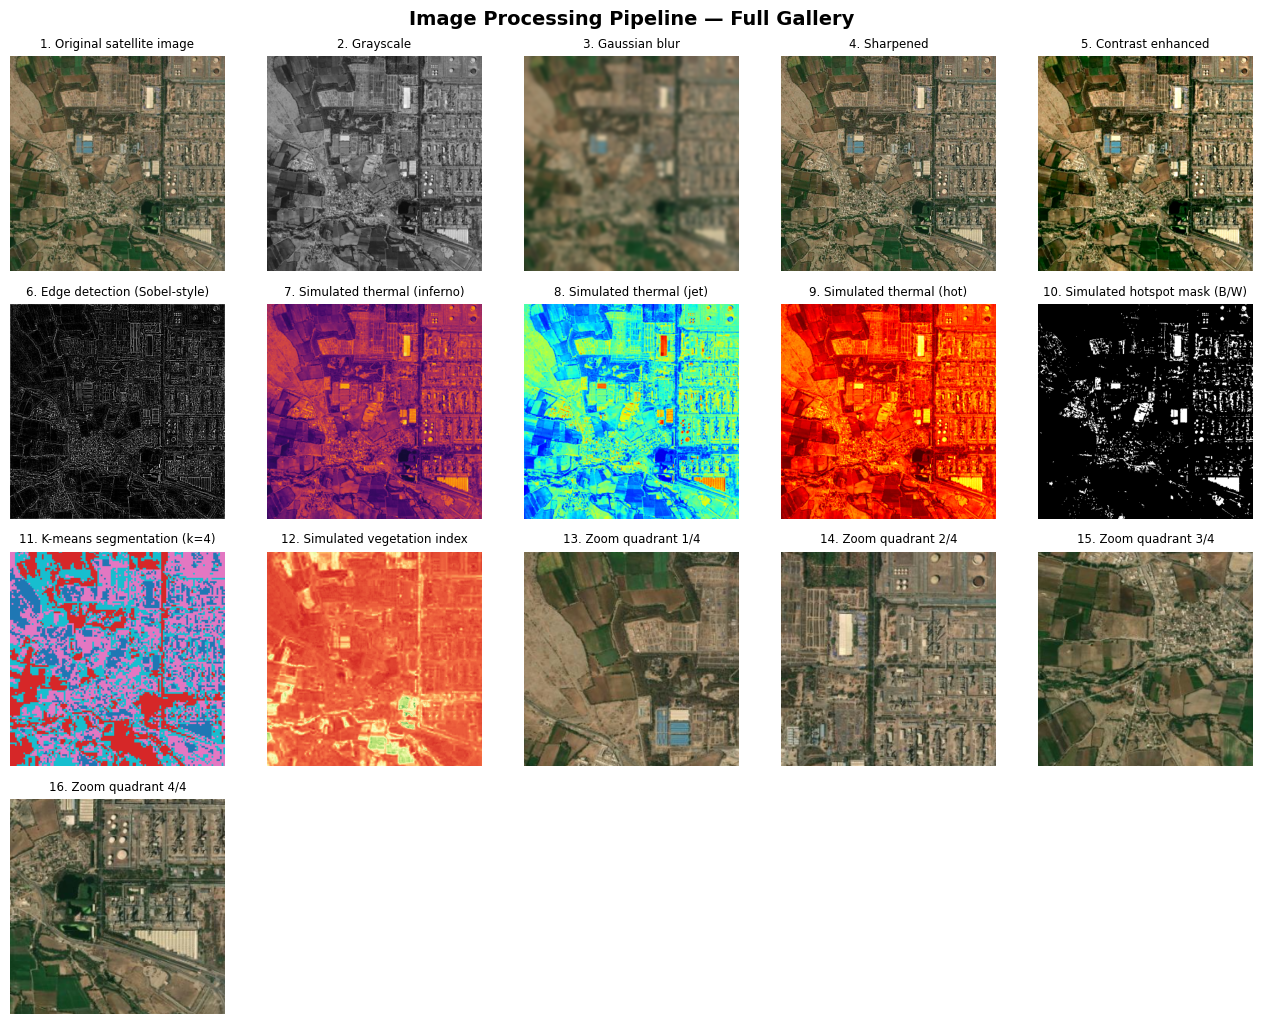

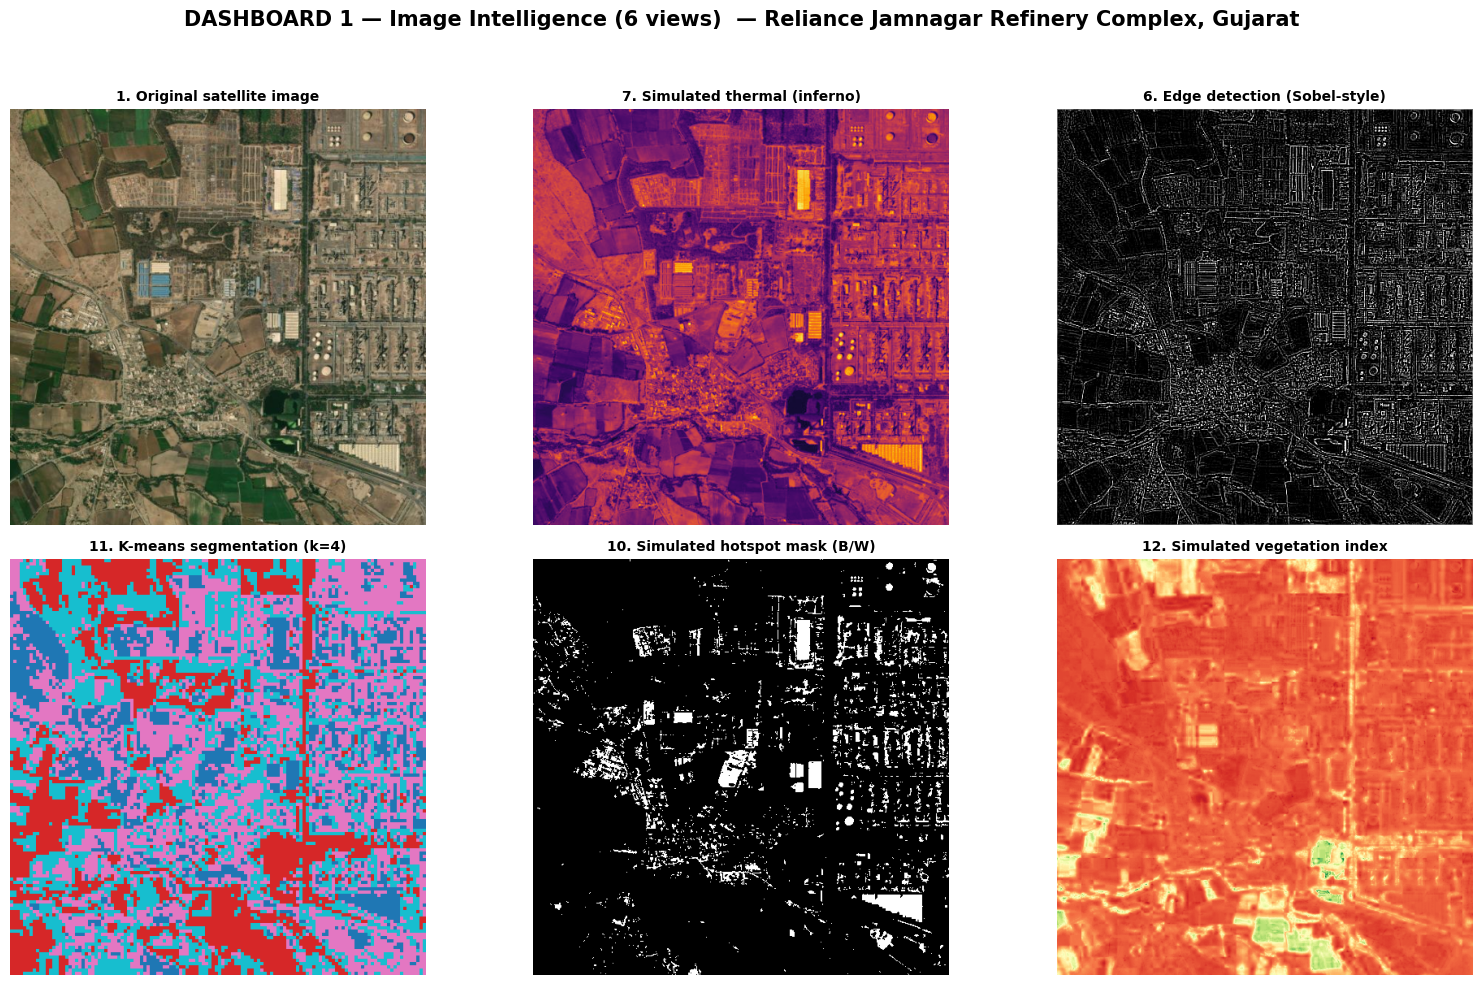

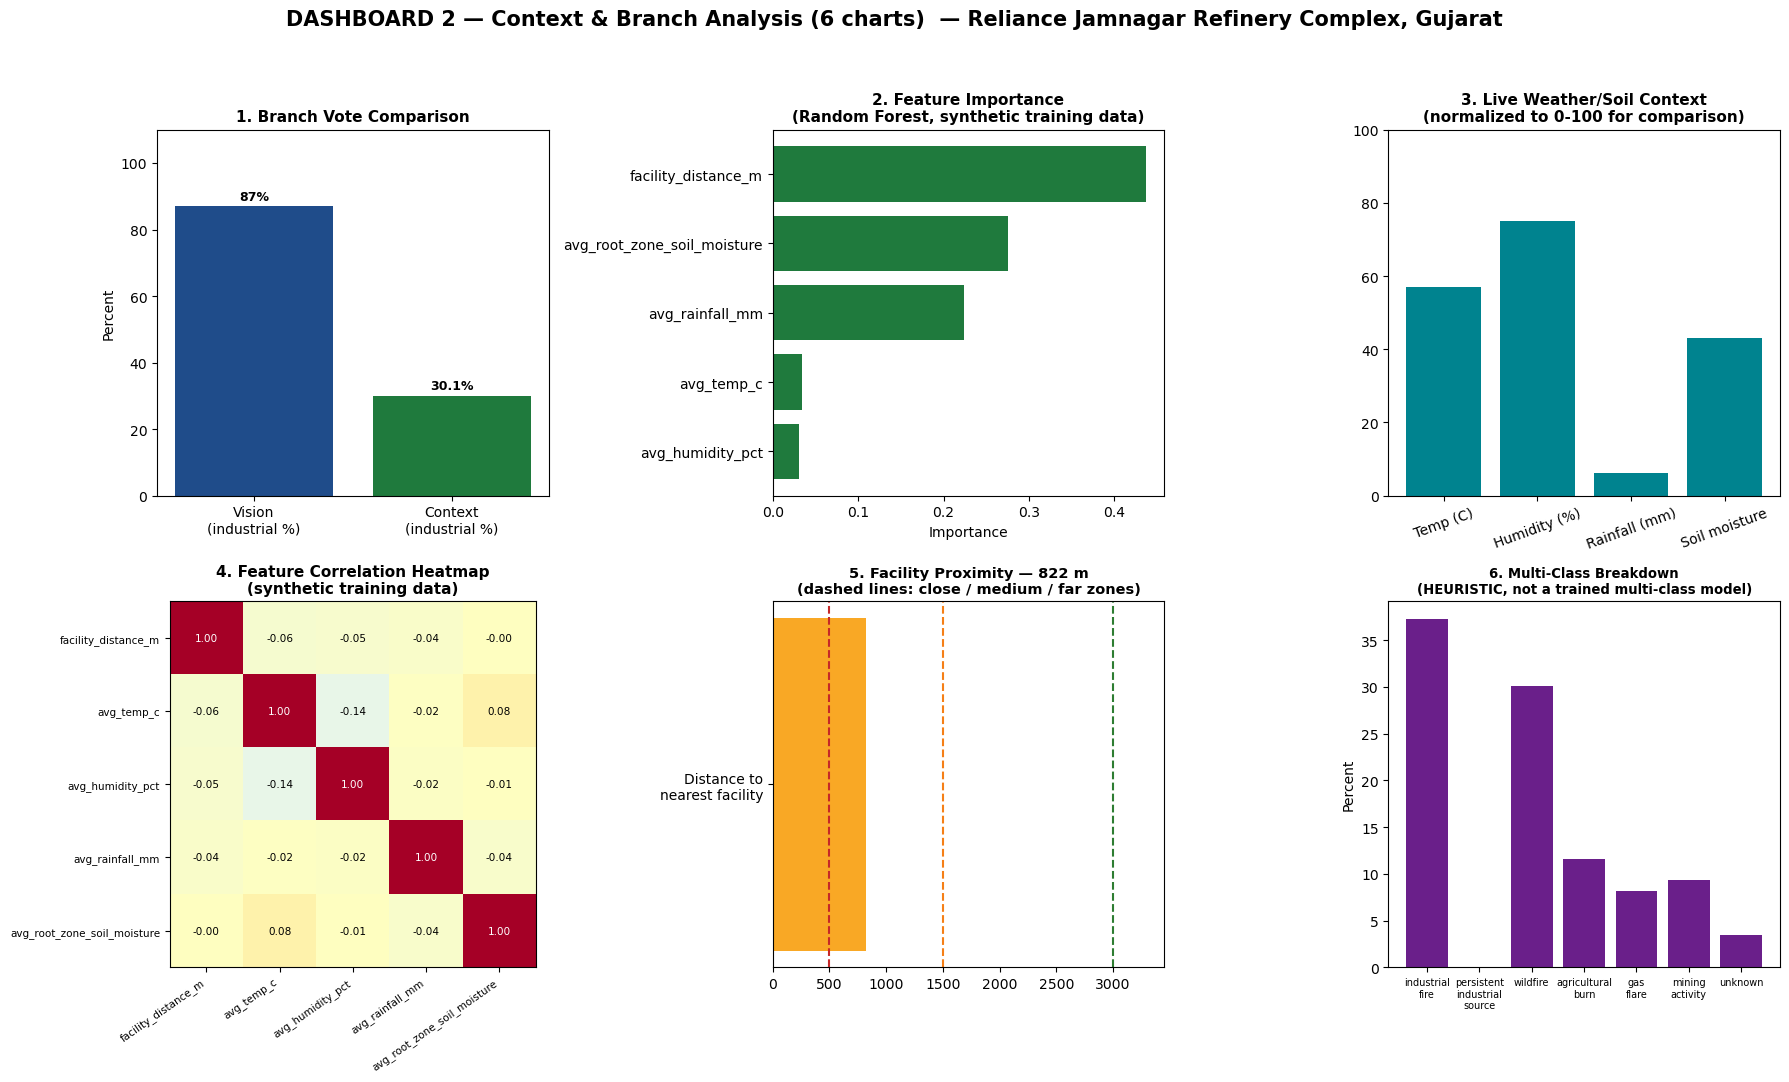

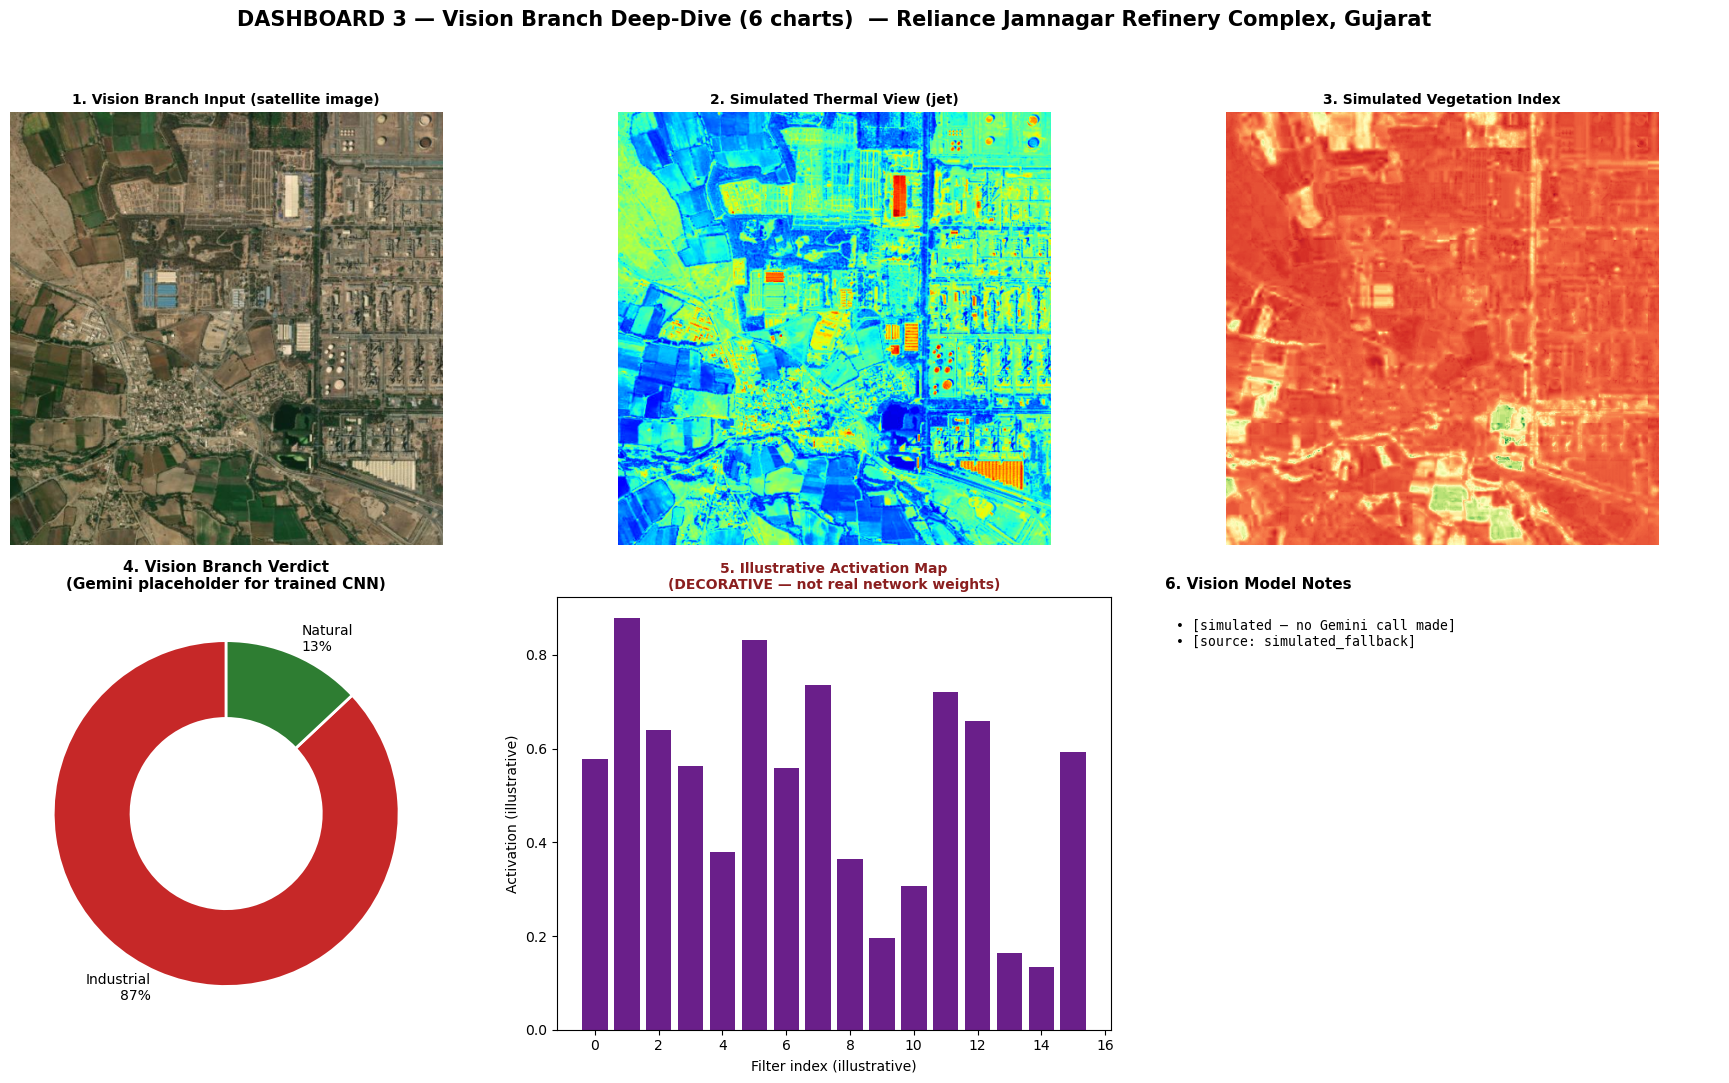

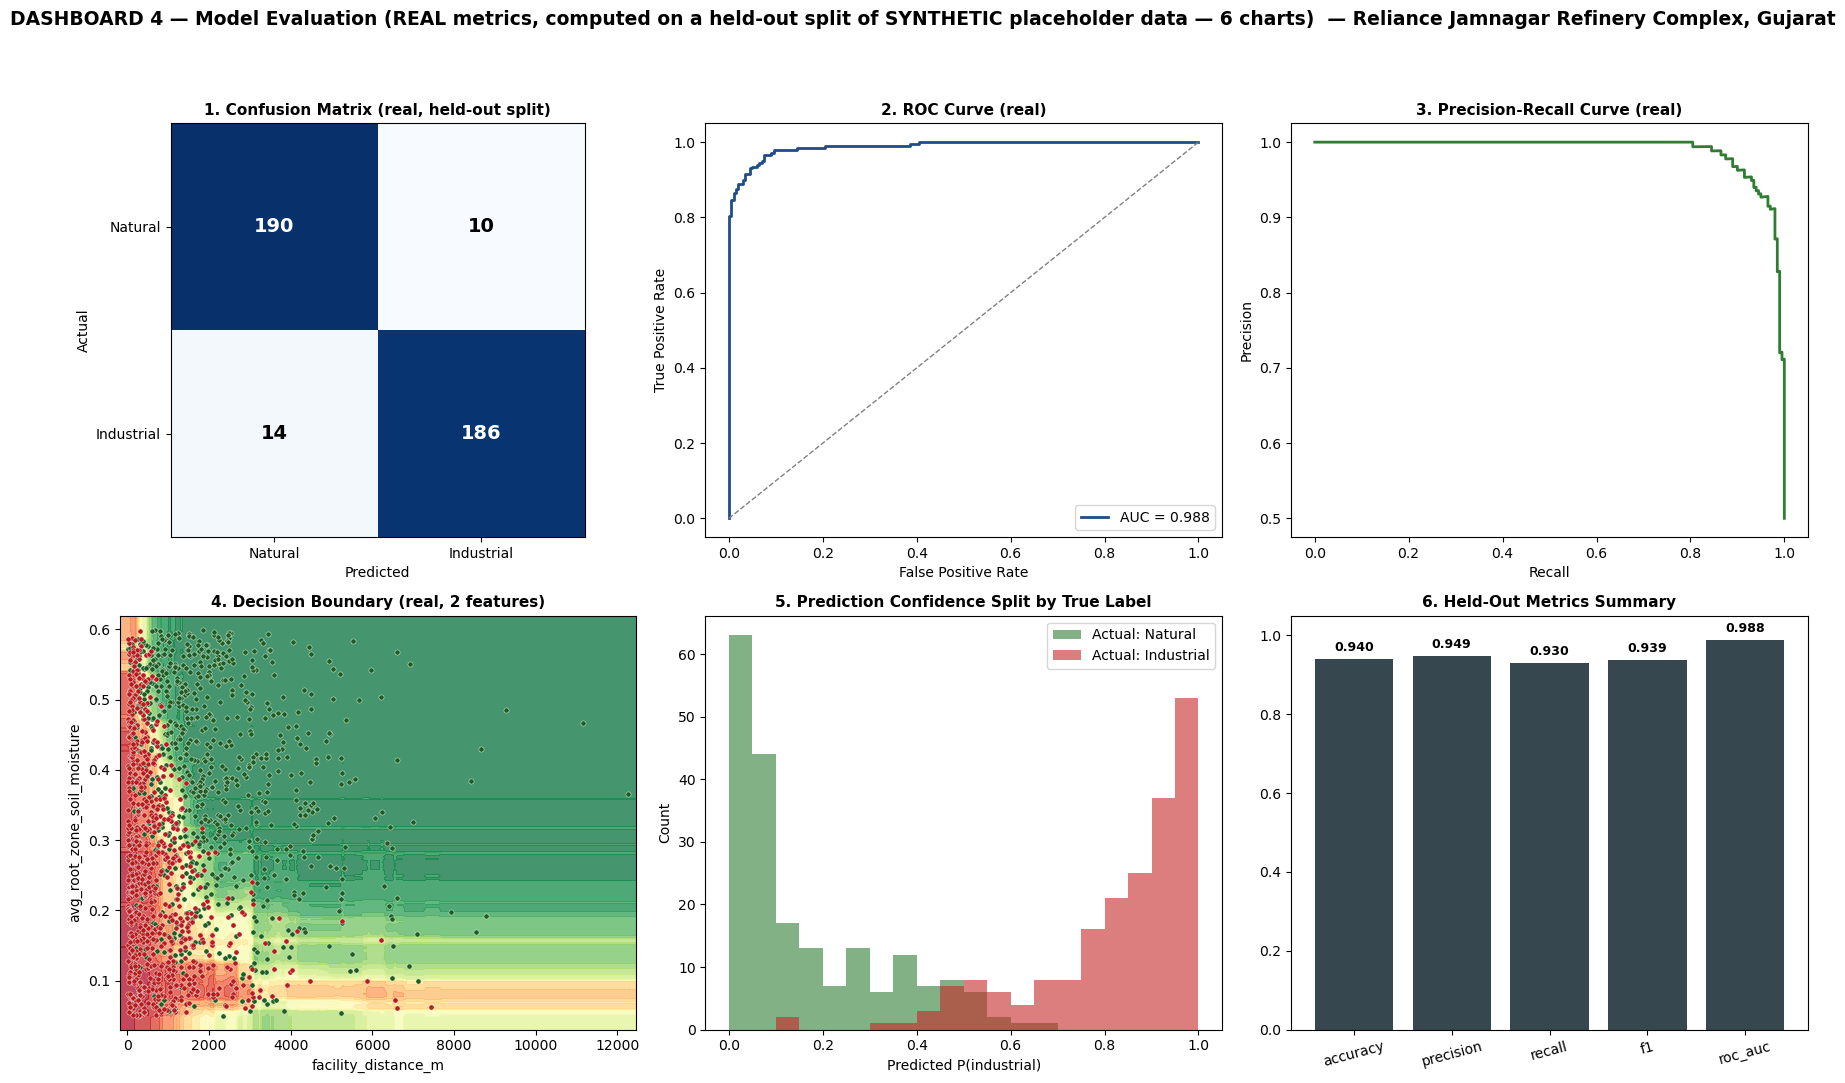

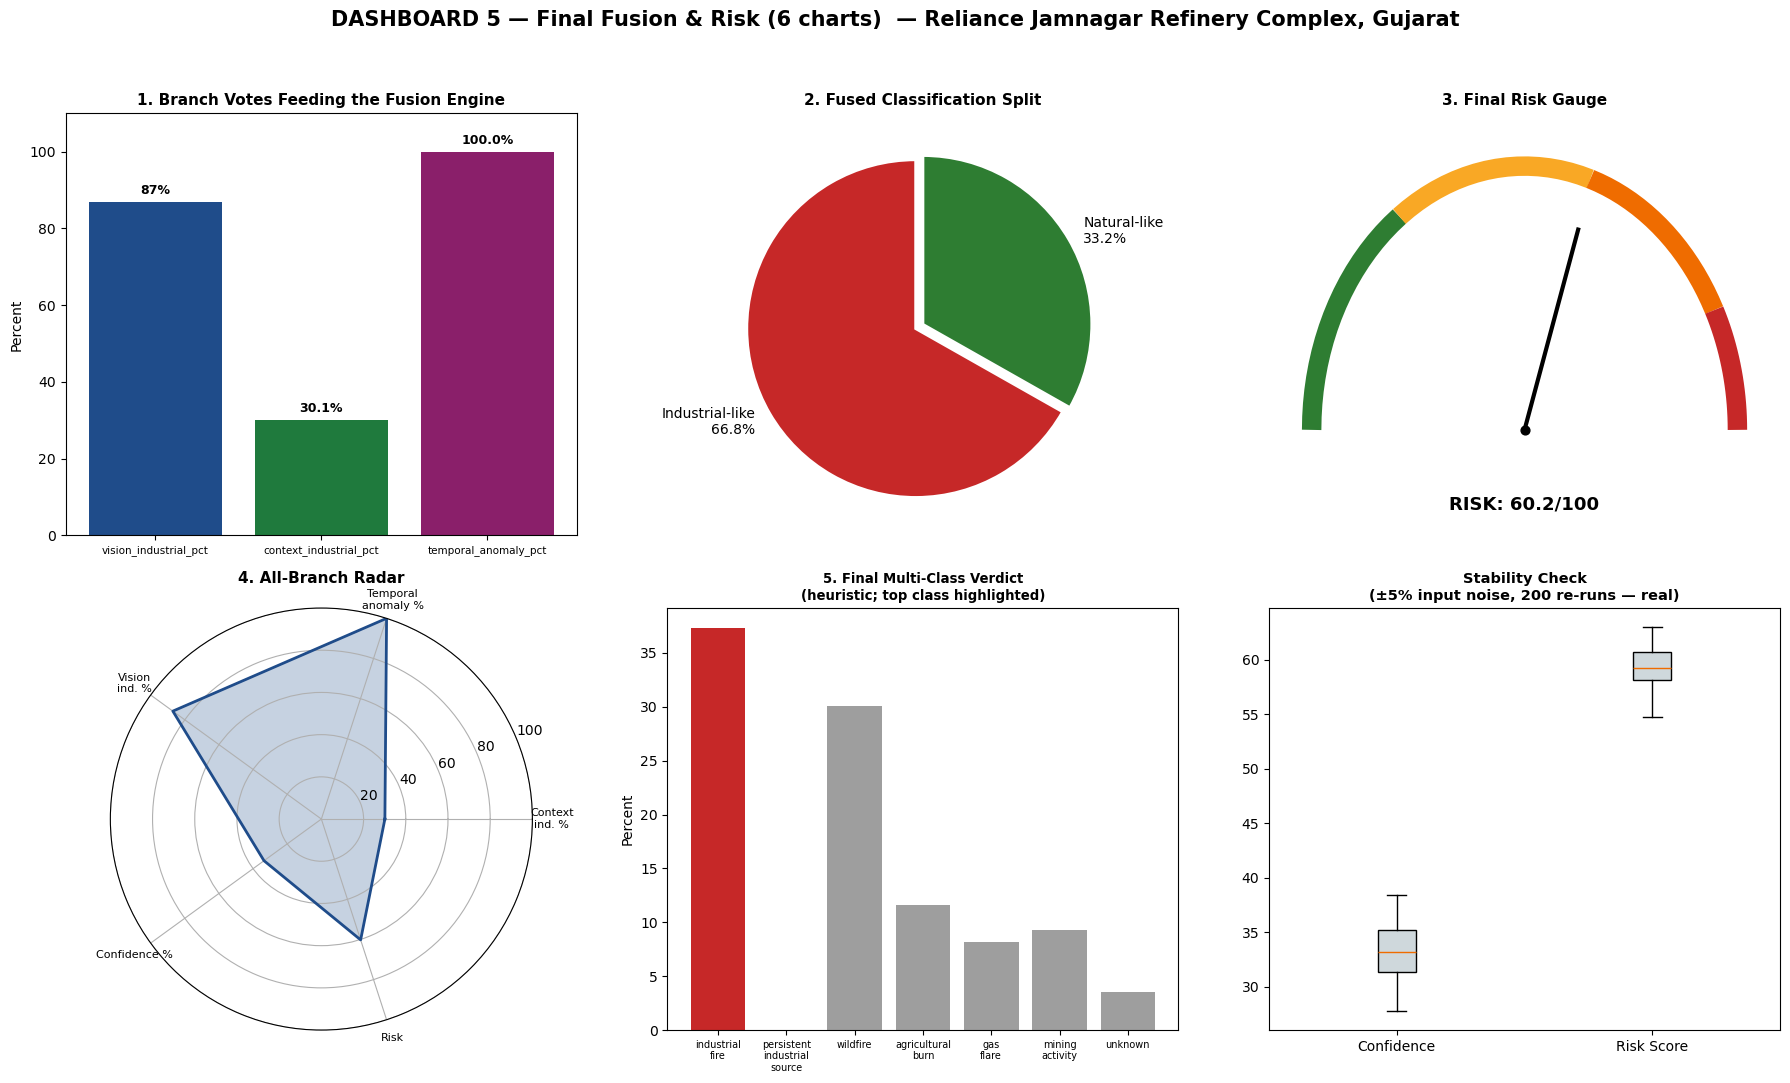


######################################################################
#  FINAL VERDICT
######################################################################
  Classification : Industrial Fire
  Confidence     : 33.6%
  Risk Score     : 60.2/100
  Nearest facility: chimney (822.1 m away)
######################################################################



In [20]:
jamnagar = DEMO_LOCATIONS["jamnagar_refinery"]
result = pipeline.run_full_pipeline(
    jamnagar["lat"], jamnagar["lon"],
    gemini_model=gemini_model,
    label=jamnagar["label"],
)


### Interactive event map (real, clickable Leaflet map — not a screenshot)

In [21]:
result["event_map"]

## 5. Multi-site comparison — does it actually tell these apart?

Runs the same three branches + fusion across all five real locations (persistent industrial source, underground coal fire, gas flare, agricultural burn, wildfire) and shows one head-to-head chart. This is the real test of the system's whole premise: the same raw 'something is hot here' signal, five completely different real causes.

In [ ]:
multi = pipeline.run_multi_site_comparison(DEMO_LOCATIONS, gemini_model=gemini_model)


COMPARISON SITE — Reliance Jamnagar Refinery Complex, Gujarat
  Why this site: The single largest oil refining complex on Earth — roughly 1.24 million barrels/day of capacity. Its flare stacks and process heaters run hot every single night of the year. This is the textbook 'persistent industrial source': FIRMS lights up here on repeat, and it is never a wildfire and never news.
[image_fetcher] got image from Esri World Imagery
[vision_model] Gemini call failed, falling back to simulated response: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use models/gemini-3.6-flash for the latest features and improvements. We recommend you to use the Interactions API.', 'status': 'NOT_FOUND'}}
  Predicted: industrial_fire  |  Top multi-class guess: industrial_fire  |  Risk: 60.2  |  Expected: persistent_industrial_source

COMPARISON SITE — Jharia Coalfield, Jharkhand
  Why this site: Underground

### India-wide interactive map of every demo site

In [ ]:
multi["multi_map"]

## 6. Run it on your own coordinates

Drop in any latitude/longitude — a real FIRMS hotspot, a suspected facility, anywhere — and get
the full 5-dashboard breakdown.

In [ ]:
MY_LAT = 22.3350   # <- replace with your own latitude
MY_LON = 69.8397   # <- replace with your own longitude
MY_LABEL = "Custom location"

custom_result = pipeline.run_full_pipeline(MY_LAT, MY_LON, gemini_model=gemini_model, label=MY_LABEL)
custom_result["event_map"]


---
## Recap — what to say on stage

1. **The problem**: NASA FIRMS tells you *where* it's hot, never *why*. This project resolves that ambiguity.
2. **The architecture**: 3 layers — preprocessing, 3 parallel branches (vision / context / temporal), fusion + risk scoring — exactly matching the team's design doc.
3. **What's real today**: live satellite imagery, live OSM + NASA POWER context, a genuinely trained Random Forest with real held-out evaluation metrics, real anomaly-score math, a real deterministic fusion formula, and a real Monte Carlo stability check.
4. **What's a placeholder, and why that's fine**: the vision branch uses Gemini standing in for a CNN that needs a labeled dataset to train; the tabular model's training data and the 30-day history are synthetic because no labeled dataset exists yet. Both are one-file swaps once real data arrives — that separation is the point of this architecture.
5. **The proof**: five real, famous, documented Indian sites — Jamnagar refinery, Jharia's century-old coal fire, Hazira's gas flares, Punjab's stubble-burning belt, Bandipur's wildfires — run through the exact same pipeline with no per-site tuning.

Full technical write-up: see `explain.md` in the repo root.